In this notebook, we make the paper plots regarding the fastspec catalog!!

In [1]:
import os
import sys
import glob
import numpy as np
from tqdm import trange
from astropy.io import fits
from astropy.table import Table, vstack
from astropy.convolution import convolve, Gaussian1DKernel
import astropy.units as u
import astropy.coordinates as coord
import matplotlib
import matplotlib.pyplot as plt
from astropy.table import Column
from tqdm import trange
import pandas as pd
import matplotlib.ticker as mticker
import fitsio
from astropy.table import Table, vstack
from astropy import units as u
from astropy.coordinates import SkyCoord
from easyquery import Query, QueryMaker
from scipy.stats import binomtest
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import LogNorm
from matplotlib.colors import ListedColormap, BoundaryNorm
import h5py
from astropy.cosmology import Planck18
import glob
from matplotlib.lines import Line2D

rootdir = '/global/u1/v/virajvm/'
sys.path.append(os.path.join(rootdir, 'DESI2_LOWZ/desi_dwarfs/code'))

sys.path.append(os.path.join(rootdir, 'DESI2_LOWZ/desi_dwarfs/code/nebular_stuff'))

sys.path.append(os.path.join(rootdir, 'DESI2_LOWZ/desi_dwarfs/code/stacking_analysis'))


from desi_lowz_funcs import make_subplots, match_c_to_catalog, print_radecs, process_img
from desi_lowz_funcs import calc_normalized_dist, sdss_rgb, get_scrollable_pdfs
from desi_lowz_funcs import find_objects_nearby, print_radecs
# from construct_dwarf_galaxy_catalogs import process_sga_matches

import warnings
from astropy.wcs import FITSFixedWarning

from desi_lowz_funcs import plot_2d_dist, make_subplots

# Suppress just FITSFixedWarning
warnings.filterwarnings('ignore', category=FITSFixedWarning)

from sfr_and_metallicity import compute_o32, compute_r32
from sfr_and_metallicity import line_snr_mask
from catalog_paper_plots import make_cmap
from catalog_paper_plots import make_cmap
import cmasher as cmr
from scipy.stats import gaussian_kde

from pn_functions import compute_direct_metallicities

%load_ext autoreload
%autoreload 2




In [2]:
# import sys
# !{sys.executable} -m pip install pyneb

In [3]:

import matplotlib as mpl

mpl.rcParams.update({
    # --- Fonts (your existing sizes + cmr10 serif from new style) ---
    'font.family':                 'serif',
    'font.serif':                  'cmr10',
    'font.size':                   11,
    'mathtext.fontset':            'cm',
    'axes.unicode_minus':          False,
    'axes.formatter.use_mathtext': True,
    'axes.labelsize':              12,
    'axes.titlesize':              12,
    'xtick.labelsize':             10,
    'ytick.labelsize':             10,
    'legend.fontsize':             11,

    # --- Axes ---
    'axes.linewidth':              1.0,
    'axes.xmargin':                0.05,

    # --- X ticks: in, all sides, minor ticks on ---
    'xtick.direction':             'in',
    'xtick.top':                   True,
    'xtick.minor.visible':         True,
    'xtick.major.top':             True,
    'xtick.minor.top':             True,
    'xtick.major.size':            3.5,
    'xtick.minor.size':            2.0,
    'xtick.major.width':           1.0,
    'xtick.minor.width':           0.8,
    'xtick.major.pad':             4,
    'xtick.minor.pad':             4,

    # --- Y ticks: in, all sides, minor ticks on ---
    'ytick.direction':             'in',
    'ytick.right':                 True,
    'ytick.minor.visible':         True,
    'ytick.major.right':           True,
    'ytick.minor.right':           True,
    'ytick.major.size':            3.5,
    'ytick.minor.size':            2.0,
    'ytick.major.width':           1.0,
    'ytick.minor.width':           0.8,
    'ytick.major.pad':             4,
    'ytick.minor.pad':             4,

    # --- Legend ---
    'legend.frameon':              False,
    'legend.edgecolor':            'k',
    'legend.framealpha':           0,

    # --- Figure / savefig / misc ---
    'figure.facecolor':            'w',
    'image.aspect':                'auto',
    'image.cmap':                  'magma',
    'savefig.format':              'pdf',
    'savefig.bbox':                'standard',
    'savefig.dpi':                 300,
    'savefig.transparent':         False,
    'errorbar.capsize':            0,
    'lines.markersize':            5,
    'hist.bins':                   'auto',
})


MARGIN_LABEL  = 0.9   # edge with axis label + tick labels
MARGIN_TICKS  = 0.45  # edge with only tick labels (no axis label)
MARGIN_PAD    = 0.2   # edge with nothing
MARGIN_SHARED = 0.1   # gap between panels sharing an axis
MARGIN_SPLIT  = 0.7   # gap between panels with independent axes
MARGIN_CBAR   = 1.1   # edge with a colorbar



In [4]:
sample_colors = {"BGS_BRIGHT" : "#882255", "BGS_FAINT": "#CC6677", "LOWZ":"#DDCC77", "ELG": "#88CCEE" }
izw18_tgid = 39633324993414901


In [5]:
# from consolidate_photometry import get_fastspec_fit_catalog_V2


In [6]:
# get_fastspec_fit_catalog_V2()


In [7]:
# Path to the catalog
filename = "/pscratch/sd/v/virajvm/desi_dwarf_catalogs/dr1/v1.0/desi_dr1_dwarf_catalog.fits"

# Option 1: load the MAIN extension directly as an Astropy Table
main = Table.read(filename, hdu="MAIN")

# Option 2: load the SPEC_DERIVED extension (dwarf catalog)
spec_derived = Table.read(filename, hdu="SPEC_DERIVED")

fastspec = Table.read(filename, hdu="FASTSPEC")


### saving catalog for fastspecfit custom run!!

In [2]:
# ## save the file for custom fastspec fit run!
# main.write("/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/desi_dr1_dwarfs.fits",overwrite=True)

In [3]:

# import fitsio, numpy as np
# t = fitsio.read('/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/desi_dr1_dwarfs.fits',
#                 columns=['HEALPIX','TARGETID'])
# pix, counts = np.unique(t['HEALPIX'], return_counts=True)
# print(f'{len(t):,d} targets across {len(pix):,d} healpix pixels')
# print(f'avg {counts.mean():.1f} targets/pixel, max {counts.max()}, median {np.median(counts):.0f}')


## Validate the new fastspecfit with old fastspecfit measurements!

In [4]:
# TODO:
# 1: Validate the two fastspecfit
# 2: update text description of hte new fastspecfit run
# 2: git commit,and then add the code to make the new fastspecfit stuff including new SFR measurements (assuming case_b + 2.86 + joint fiting of hab hbg) .. update hte catalog and code to make the final catalog. we will add the new extension
# 3: Then explore the dust corrections, balmer decrements, and stacked spectra in bins of various sSFRs, how reliable is 2.86 assumption?
# 4: once dust corrections are validated, move onto ELG vs. non-ELG plots and then update everything else
# 5: update stellar mass discussion and then finalize text!

In [42]:
# new_fspec_hdus = fits.open("/pscratch/sd/v/virajvm/desi_dwarf_catalogs/fastspecfit_custom_run/iron/catalogs/fastspec-iron-sample.fits")

In [5]:
new_fspec_cat = Table.read("/pscratch/sd/v/virajvm/desi_dwarf_catalogs/fastspecfit_custom_run/iron/catalogs/fastspec-iron-dr1-dwarfs.fits", hdu = 3)
      

In [8]:
new_fspec_cat[new_fspec_cat["TARGETID"] ==39633025151011172 ]["OIII_4363_FLUX","OIII_4363_FLUX_IVAR"]

OIII_4363_FLUX,OIII_4363_FLUX_IVAR
float32,float32
0.0032535137,6.913428e+06


In [44]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import join

# 1. Find common columns
cols1 = set(fastspec.colnames)
cols2 = set(new_fspec_cat.colnames)
common_cols = sorted(cols1 & cols2)
common_cols.remove('TARGETID')  # key, not for comparison

print(f"Columns only in fastspec:      {sorted(cols1 - cols2)}")
print(f"Columns only in new_fspec_cat: {sorted(cols2 - cols1)}")
print(f"Common columns ({len(common_cols)}): {common_cols}")

# 2. Join on TARGETID so rows line up
#    table_names sets the suffix for duplicated columns -> _1, _2
matched = join(
    fastspec[['TARGETID'] + common_cols],
    new_fspec_cat[['TARGETID'] + common_cols],
    keys='TARGETID',
    table_names=['1', '2'],
    join_type='inner',
)
print(f"\nMatched {len(matched)} rows on TARGETID")


Columns only in fastspec:      ['DEC', 'DELTA_MAG_G_BASS2DECAM', 'DELTA_MAG_G_DECAM2SDSS', 'DELTA_MAG_G_KCORR', 'DELTA_MAG_G_NEB', 'DELTA_MAG_R_BASS2DECAM', 'DELTA_MAG_R_DECAM2SDSS', 'DELTA_MAG_R_KCORR', 'DELTA_MAG_R_NEB', 'DN4000', 'DN4000_IVAR', 'DN4000_MODEL', 'DN4000_OBS', 'LOGMSTAR_FASTSPEC', 'LOG_HALPHA_SFR_FIBER', 'LOG_MSTAR_24_FIBER', 'LOG_SFR_HALPHA', 'LOG_SFR_HALPHA_ERR', 'MAG_G_BASS_MODEL_WEMI', 'MAG_G_DECAM_MODEL_NOEMI', 'MAG_G_DECAM_MODEL_WEMI', 'MAG_G_FIBER_NOEMI', 'MAG_G_FIBER_NOEMI_ERR', 'MAG_G_SDSS_MODEL_NOEMI', 'MAG_G_SDSS_Z0_MODEL_NOEMI', 'MAG_R_BASS_MODEL_WEMI', 'MAG_R_DECAM_MODEL_NOEMI', 'MAG_R_DECAM_MODEL_WEMI', 'MAG_R_FIBER_NOEMI', 'MAG_R_FIBER_NOEMI_ERR', 'MAG_R_SDSS_MODEL_NOEMI', 'MAG_R_SDSS_Z0_MODEL_NOEMI', 'RA', 'VDISP', 'VDISP_IVAR', 'Z_GAS_R23_N2']
Columns only in new_fspec_cat: ['ARIII_7135_AMP', 'ARIII_7135_AMP_IVAR', 'ARIII_7135_BOXFLUX', 'ARIII_7135_BOXFLUX_IVAR', 'ARIII_7135_CHI2', 'ARIII_7135_CONT', 'ARIII_7135_CONT_IVAR', 'ARIII_7135_EW', 'ARIII_7135

In [62]:
import numpy as np
import matplotlib.pyplot as plt

def snr_cut_and_plot(merged, line='HALPHA_FLUX', snr_min=3.0, ax=None):
    """
    Apply SNR > snr_min cut on the new catalog ('_2') for the given line,
    then make a 1:1 scatter of fastspec ('_1') vs new ('_2') values.

    Parameters
    ----------
    merged : astropy.table.Table
        Joined catalog with '_1' (fastspec) and '_2' (new) suffixes.
    line : str
        Flux column base name, e.g. 'HALPHA_FLUX'. Must have a matching
        '<line>_IVAR' column in the table.
    snr_min : float
        Minimum SNR (flux * sqrt(ivar)) required in the new catalog.
    ax : matplotlib axis, optional
        If given, plot into this axis instead of making a new figure.

    Returns
    -------
    cut : astropy.table.Table
        Rows of `merged` passing the SNR cut on the new catalog.
    """
    flux_1, flux_2 = f'{line}_1', f'{line}_2'
    ivar_1, ivar_2 = f'{line}_IVAR_1', f'{line}_IVAR_2'

    for col in (flux_1, flux_2, ivar_1, ivar_2):
        if col not in merged.colnames:
            raise KeyError(f"Column '{col}' not found in merged catalog.")

    # SNR on the new catalog
    f2 = np.asarray(merged[flux_2], dtype=float)
    iv2 = np.asarray(merged[ivar_2], dtype=float)
    snr2 = f2 * np.sqrt(np.clip(iv2, 0, None))

    mask = np.isfinite(snr2) & (snr2 > snr_min) 
    cut = merged[mask]
    print(f"{line}: kept {mask.sum()} / {len(merged)} rows with SNR_2 > {snr_min}")

    # plot
    x = np.asarray(cut[flux_1], dtype=float)
    y = np.asarray(cut[flux_2], dtype=float)
    good = np.isfinite(x) & np.isfinite(y)
    x, y = x[good], y[good]

    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 6))

    ax.scatter(x, y, s=0.5, alpha=0.4, rasterized=True)
    if len(x):
        lo = min(x.min(), y.min())
        hi = max(x.max(), y.max())
        ax.plot([lo, hi], [lo, hi], 'r-', lw=1, label='1:1')
        ax.set_xlim(lo, hi)
        ax.set_ylim(lo, hi)

    ax.set_xlabel(f'{line} (fastspec)')
    ax.set_ylabel(f'{line} (new)')
    ax.set_yscale("log")
    ax.set_xscale("log")
    ax.set_xlim([1,3e3])
    ax.set_ylim([1,3e3])
    ax.set_title(fr'{line}  (N={len(x)})')
    ax.legend(loc='upper left', fontsize=9)
    ax.set_aspect('equal', adjustable='box')

    plt.tight_layout()
    return cut


# Example:
# cut_cat = snr_cut_and_plot(matched, line='HALPHA_FLUX', snr_min=3.0)

HBETA_FLUX: kept 302576 / 460740 rows with SNR_2 > 5.0


/tmp/ipykernel_158423/3738497724.py:69: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


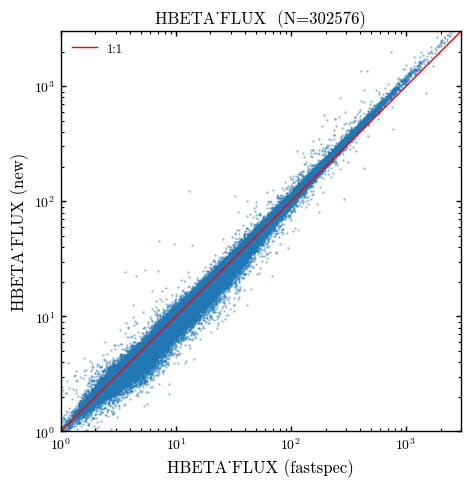

In [78]:

fig, ax = make_subplots(nrow=1,ncol=1,return_fig=True, plot_size=4)

cut_cat = snr_cut_and_plot(matched, line='HBETA_FLUX', snr_min=5.0, ax=ax[0])

plt.show()

Plot 1) Comparing the nebular diagnostics of dwarfs in different samples ELG, BGS_BRIGHT for example

In [8]:
photo_mask = (main["DWARF_MASKBIT"] == 0) & (main["LOG_MSTAR_M24"] < 9)

#get the snr > 3 mask
snr_mask = line_snr_mask(fastspec, line_names=["HBETA","HALPHA","OIII_5007", "OIII_4959","OII_3726"],snr_val=3, min_lines=5)

fspec_cat = fastspec[photo_mask & snr_mask]
main_cat = main[photo_mask & snr_mask]

dwarf_o32 = compute_o32(fspec_cat)
dwarf_r32 = compute_r32(fspec_cat)



ValueError: line_flux_type must be 'FLUX' or 'BOXFLUX' (got None); pass explicitly or set sfr_and_metallicity.line_flux_type

In [ ]:
# === For q = 3e8 ===
oh_q3e8 = np.array([
    7.627891156462585,
    7.9326530612244905,
    8.231972789115646,
    8.631972789115647,
    8.931292517006803,
    9.10544217687075,
    9.233333333333334,
    9.407482993197279,
])

# === For q = 8e7 ===
oh_q8e7 = np.array([
    7.630612244897959,
    7.9326530612244905,
    8.23469387755102,
    8.631972789115647,
    8.931292517006803,
    9.108163265306123,
    9.233333333333334,
    9.404761904761905,
])

oh_list = 0.5*(oh_q3e8 + oh_q8e7)

In [ ]:
# ## get the kewley and dopita photoionization tracks

# #for q = 3e8

# #12+[o/h], r32
# 7.627891156462585, 0.6521764534034471
# 7.9326530612244905, 0.851614081215308
# 8.231972789115646, 0.9651475314051999
# 8.631972789115647, 0.8803315804849544
# 8.931292517006803, 0.4999999999999998
# 9.10544217687075, -0.09539146947122479
# 9.233333333333334, -0.5352322524101671
# 9.407482993197279, -1.5654396728016367
# #q, o32

# 8.479108635097493, 1.417085427135678
# 8.479108635097493, 1.2763819095477387
# 8.479108635097493, 1.0686767169179228
# 8.481894150417826, 0.793969849246231
# 8.481894150417826, 0.45226130653266305
# 8.479108635097493, 0.010050251256281229
# 8.481894150417826, -0.4857621440536013
# 8.47632311977716, -1.2696817420435513


# #for q = 8e7

# #12+[o/h], r32
# 7.630612244897959, 0.4857727139935728
# 7.9326530612244905, 0.7227797253870872
# 8.23469387755102, 0.8846333625474727
# 8.631972789115647, 0.8803315804849544
# 8.931292517006803, 0.6019938650306746
# 9.108163265306123, 0.1622845457201283
# 9.233333333333334, -0.2882997370727436
# 9.404761904761905, -1.409772129710781

# #q, o32
# 7.902506963788301, 0.7135678391959797
# 7.902506963788301, 0.5862646566164151
# 7.902506963788301, 0.41876046901172503
# 7.905292479108635, 0.19095477386934667
# 7.902506963788301, -0.07035175879397038
# 7.902506963788301, -0.22445561139028491
# 7.902506963788301, -0.512562814070352
# 7.905292479108635, -1.0083752093802345


r32_q3e8 = [0.6522, 0.8516, 0.9651, 0.8803, 0.5000, -0.0954, -0.5352, -1.5654]
o32_q3e8 = [1.4171, 1.2764, 1.0687, 0.7940, 0.4523, 0.0101, -0.4858, -1.2697]

r32_q8e7 = [0.4858, 0.7228, 0.8846, 0.8803, 0.6020, 0.1623, -0.2883, -1.4098]
o32_q8e7 = [0.7136, 0.5863, 0.4188, 0.1910, -0.0704, -0.2245, -0.5126, -1.0084]

print(len(oh_list), len(r32_q3e8))

#let us get smooth functional forms for this
from scipy.interpolate import UnivariateSpline 

def x_to_y(x, y, xlab, ylab):

    x = np.array(x)
    y = np.array(y)

    sort_inds = np.argsort(x)
    
    spl = UnivariateSpline(x[sort_inds], y[sort_inds],s=0.01)

    # Evaluate on a fine grid
    xfit = np.linspace(-1.5, 2, 300)
    
    # Plot data and fits
    plt.figure(figsize=(3, 3))
    # plt.scatter(o32_q8e7, r32_q8e7, label="data", color="k", s=30)
    plt.scatter(x, y, label="data", color="k", s=30)
    
    plt.plot(xfit, spl(xfit), label="spline", color="darkorange", lw=2)
    
    plt.xlim([-1.5,2])
    plt.ylim([-1.5,1])
    
    plt.xlabel(f"{xlab}")
    plt.ylabel(f"{ylab}")
    plt.legend()
    plt.show()

    return spl


def oh_to_r23(oh_list, r32):
    spl = UnivariateSpline(oh_list, r32,s=0.0)

    # Evaluate on a fine grid
    xfit = np.linspace(7.4, 9.5, 100)
    
    # Plot data and fits
    plt.figure(figsize=(3, 3))
    plt.scatter(oh_list, r32, label="data", color="k", s=30)
    
    plt.plot(xfit, spl(xfit), label="spline", color="darkorange", lw=2)
    
    plt.xlim([7.5,9.6])
    plt.ylim([-1.5,1.5])
    
    plt.xlabel("12+O/H")
    plt.ylabel("R32")
    plt.legend()
    plt.show()

    return spl




In [ ]:
spl_oh_to_o32_3e8 = oh_to_r23(oh_list, o32_q3e8)
spl_oh_to_o32_8e7 = oh_to_r23(oh_list, o32_q8e7)


In [ ]:
spl_o32_to_r23_3e8 = x_to_y(o32_q3e8, r32_q3e8, xlab="O32",ylab="R23")
spl_o32_to_r23_8e7 = x_to_y(o32_q8e7, r32_q8e7, xlab="O32",ylab="R23")

In [ ]:
spl_oh_to_r23_3e8 = oh_to_r23(oh_list, r32_q3e8)
spl_oh_to_r23_8e7 = oh_to_r23(oh_list, r32_q8e7)


In [ ]:
def get_bgsb_massive_stuff(hpx):
    #opening some random fastspec file that has a lot of 
    fspec_hdu = fits.open(f"/global/cfs/cdirs/desi/public/dr1/vac/dr1/fastspecfit/iron/v3.0/catalogs/fastspec-iron-main-bright-nside1-hp{hpx}.fits")

    print("Done reading file!")
    metadata = fspec_hdu["METADATA"].data
    specphot = fspec_hdu["SPECPHOT"].data
    fastspec_all = fspec_hdu["FASTSPEC"].data

    zmask = (metadata["DELTACHI2"] > 40) & (metadata["SPECTYPE"] == "GALAXY")
    mstar_mask = (specphot["LOGMSTAR"] > 10)
    tot_mask = zmask & mstar_mask

    fastspec_non_dwarf = Table(fastspec_all[tot_mask])

    print("Obtained filtered fastspec table!")

    
    snr_non_dwarf_mask = line_snr_mask(fastspec_non_dwarf, line_names=["HBETA","HALPHA","OIII_5007", "OIII_4959","OII_3726"],snr_val=3, min_lines=5)

    all_o32 = compute_o32(fastspec_non_dwarf[snr_non_dwarf_mask])
    all_r32 = compute_r32(fastspec_non_dwarf[snr_non_dwarf_mask])

    return all_r32, all_o32


all_r32_1, all_o32_1 = get_bgsb_massive_stuff("01")
all_r32_2, all_o32_2 = get_bgsb_massive_stuff("06")

#let us stack these
all_r32 = np.concatenate([all_r32_1, all_r32_2])
all_o32 = np.concatenate([all_o32_1, all_o32_2])



In [126]:
## I should probably dust correct ?

import numpy as np
from astropy.io import ascii

# Read the MRT file. The header bytes (1-373) match the CDS format,
# but the file as given has only the data rows — so we specify columns by position.

colspecs = [
    (0, 3),     # ObjID
    (4, 14),    # RAdeg
    (15, 24),   # DEdeg
    (25, 33),   # zspec
    (169, 172), # log(M/Msun)
    (173, 180), # 12+log(O/H)
    (195, 202), # [OII]3727 flux
    (267, 274), # Hbeta flux
    (281, 289), # [OIII]4959 flux
    (296, 304), # [OIII]5007 flux
]
colnames = ['ObjID', 'RA', 'Dec', 'z', 'logM', 'logOH',
            'OII3727', 'Hbeta', 'OIII4959', 'OIII5007']

# Read as fixed-width
from astropy.io import ascii
tbl = ascii.read('/global/homes/v/virajvm/DESI2_LOWZ/desi_dwarfs/data/yang17_blueberries.txt',
                 format='fixed_width_no_header',
                 col_starts=[c[0] for c in colspecs],
                 col_ends=[c[1]-1 for c in colspecs],
                 names=colnames)

# Convert sentinel values to NaN
for col in ['OII3727', 'Hbeta', 'OIII4959', 'OIII5007', 'logOH']:
    arr = np.array(tbl[col], dtype=float)
    arr[arr < -90] = np.nan   # catches both -99 and -999
    tbl[col] = arr

# Compute line ratios
OII   = np.array(tbl['OII3727'], dtype=float)   # doublet sum as reported
OIII  = np.array(tbl['OIII5007'], dtype=float)  # 5007 only
OIII_full = (np.array(tbl['OIII4959'], dtype=float)
             + np.array(tbl['OIII5007'], dtype=float))  # 4959 + 5007
Hbeta = np.array(tbl['Hbeta'], dtype=float)

# O32 = [OIII]5007 / [OII]3727  (Kewley & Dopita / Nakajima convention)
O32 = OIII / OII

# R23 = ([OIII]4959 + [OIII]5007 + [OII]3727) / Hbeta
R23 = (OIII_full + OII) / Hbeta

# Log versions for plotting
logO32_BB_ini = np.log10(O32)
logR23_BB_ini = np.log10(R23)

logO32_BB = logO32_BB_ini[~np.isnan(logO32_BB_ini) & ~np.isnan(logR23_BB_ini)]
logR23_BB = logR23_BB_ini[~np.isnan(logO32_BB_ini) & ~np.isnan(logR23_BB_ini)]

print(f"N galaxies: {len(logR23_BB)}")
print(f"log O32: median={np.nanmedian(logO32_BB):.2f}, "
      f"range=[{np.nanmin(logO32_BB):.2f}, {np.nanmax(logO32_BB):.2f}]")
print(f"log R23: median={np.nanmedian(logR23_BB):.2f}, "
      f"range=[{np.nanmin(logR23_BB):.2f}, {np.nanmax(logR23_BB):.2f}]")

N galaxies: 39
log O32: median=1.10, range=[-0.42, 1.80]
log R23: median=0.94, range=[0.61, 1.41]


/tmp/ipykernel_158423/4075712513.py:46: RuntimeWarning: invalid value encountered in true_divide
  O32 = OIII / OII
/tmp/ipykernel_158423/4075712513.py:49: RuntimeWarning: invalid value encountered in true_divide
  R23 = (OIII_full + OII) / Hbeta


In [127]:
import numpy as np
from astropy.io import ascii

tbl = ascii.read('/global/homes/v/virajvm/DESI2_LOWZ/desi_dwarfs/data/yang17_greenpeas.txt',
                 format='cds')   # use 'mrt' instead if your astropy is recent

print(tbl.colnames)   # sanity-check the exact names

OII      = np.array(tbl['[OII]3727'],  dtype=float)
Hbeta    = np.array(tbl['Hbeta'],      dtype=float)
OIII4959 = np.array(tbl['[OIII]4959'], dtype=float)
OIII5007 = np.array(tbl['[OIII]5007'], dtype=float)

OIII_full = OIII4959 + OIII5007
OIII      = OIII5007

O32 = OIII / OII
R23 = (OIII_full + OII) / Hbeta

logO32_GP_ini = np.log10(O32)
logR23_GP_ini = np.log10(R23)
good = ~np.isnan(logO32_GP_ini) & ~np.isnan(logR23_GP_ini)
logO32_GP = logO32_GP_ini[good]
logR23_GP = logR23_GP_ini[good]

print(f"N galaxies: {len(logR23_GP)}")
print(f"log O32: median={np.nanmedian(logO32_GP):.2f}, "
      f"range=[{np.nanmin(logO32_GP):.2f}, {np.nanmax(logO32_GP):.2f}]")
print(f"log R23: median={np.nanmedian(logR23_GP):.2f}, "
      f"range=[{np.nanmin(logR23_GP):.2f}, {np.nanmax(logR23_GP):.2f}]")

['Name', '[OII]3727', 'e_[OII]3727', '[OIII]4363', 'e_[OIII]4363', 'Hbeta', 'e_Hbeta', '[OIII]4959', 'e_[OIII]4959', '[OIII]5007', 'e_[OIII]5007', 'Halpha', 'e_Halpha', 'EW(Halpha)', '[OIII]/[OII]']
N galaxies: 43
log O32: median=0.59, range=[0.15, 1.04]
log R23: median=0.94, range=[0.79, 1.04]


In [128]:
from matplotlib.ticker import StrMethodFormatter

In [129]:
# --- compute KDE ---
def get_conts(axi, x_vals, y_vals, 
             color="purple", ls="--",lw=1):
    
    # xy = np.vstack([logR23_BB, logO32_BB])
    xy = np.vstack([x_vals, y_vals])

    kde = gaussian_kde(xy, bw_method=0.35)
    
    # grid covering your data range (with some padding)
    pad = 0.1
    x_min, x_max = logR23_BB.min() - pad, logR23_BB.max() + pad
    y_min, y_max = logO32_BB.min() - pad, logO32_BB.max() + pad
    
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 500),
                         np.linspace(y_min, y_max, 500))
    
    zz = kde(np.vstack([xx.ravel(), yy.ravel()])).reshape(xx.shape)
    
    # --- find density levels corresponding to 1σ and 2σ ---
    # i.e. the iso-density line that encloses ~68% and ~95% of the probability mass
    def density_level(kde_values, fraction):
        """Return the density threshold enclosing `fraction` of the total mass."""
        flat = np.sort(kde_values.ravel())[::-1]          # high → low
        cumsum = np.cumsum(flat) / flat.sum()
        idx = np.searchsorted(cumsum, fraction)
        return flat[min(idx, len(flat) - 1)]
    
    level_1s = density_level(zz, 0.683)   # ~68%  → 1σ
    
    from matplotlib.lines import Line2D
    
    cs = axi.contour(xx, yy, zz,
                       levels=[level_1s],
                       colors=[color],
                       linewidths=lw, linestyles=[ls],
                       zorder=4, alpha=0.85)

    return

In [135]:
import cmasher as cmr
import matplotlib.pyplot as plt

# Get the colormap
cmap = cmr.amethyst_r


/global/common/software/desi/perlmutter/desiconda/20240425-2.2.0/conda/lib/python3.10/site-packages/scipy/signal/_signaltools.py:1611: RuntimeWarning: divide by zero encountered in true_divide
  res *= (1 - noise / lVar)
/global/common/software/desi/perlmutter/desiconda/20240425-2.2.0/conda/lib/python3.10/site-packages/scipy/signal/_signaltools.py:1611: RuntimeWarning: invalid value encountered in multiply
  res *= (1 - noise / lVar)
/global/u1/v/virajvm/DESI2_LOWZ/desi_dwarfs/code/desi_lowz_funcs.py:2270: UserWarning: Log scale: values of z <= 0 have been masked
  cs = ax.contourf(X, Y, H, linewidths=np.array([1.0,0.75, 0.5, 0.25])[::-1]*lw_scale, cmap=cmap, levels = sorted(lvls),
/global/u1/v/virajvm/DESI2_LOWZ/desi_dwarfs/code/desi_lowz_funcs.py:2270: UserWarning: linewidths is ignored by contourf
  cs = ax.contourf(X, Y, H, linewidths=np.array([1.0,0.75, 0.5, 0.25])[::-1]*lw_scale, cmap=cmap, levels = sorted(lvls),
/global/u1/v/virajvm/DESI2_LOWZ/desi_dwarfs/code/desi_lowz_funcs.py

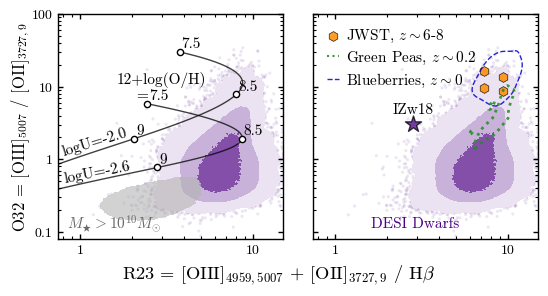

In [152]:
fig,ax = make_subplots(ncol = 2, nrow = 1, return_fig=True, plot_size = 2.25,
                      row_spacing=[0.5, MARGIN_PAD],
                      col_spacing=[0.6, MARGIN_SHARED + 0.2, MARGIN_PAD])

ax[0].scatter(np.log10(dwarf_r32), np.log10(dwarf_o32),s=5,alpha=0.1,facecolor = "#4B0082",edgecolor="none", rasterized=True)

plot_2d_dist(np.log10(dwarf_r32), np.log10(dwarf_o32), 250, 250, 
                cmin=1.e-4, cmax=1.0, smooth=10, clevs=[0,0.68,0.95,0.997],ax=ax[0], bounds= np.log10(np.array([ 0.4,20,0.1,100 ])),
            cmap = make_cmap("#4B0082"), color = "k", filled=True, label = "BGS Bright",cmap_alpha=1)

plot_2d_dist(np.log10(all_r32), np.log10(all_o32), 100, 100, 
                cmin=1.e-4, cmax=1.0, smooth=10, clevs=[0,0.68],ax=ax[0], bounds= np.log10(np.array([ 0.4,20,0.1,100 ])),
            cmap = make_cmap("dimgrey"), color = "grey", filled=True, label = "BGS Bright",cmap_alpha=0.6)


# ax[0].text(0.3,0.75,"DESI DR1\n $z < 0.5$",fontsize = 15,color = "k",transform=ax[0].transAxes, ha='center',  va='bottom')

o32_3e8_grid = np.linspace( np.min(o32_q3e8) , np.max(o32_q3e8)+0.06, 100)

#plot the photo-ionization tracks
ax[0].plot(spl_o32_to_r23_3e8(o32_3e8_grid), o32_3e8_grid, 'k', ls = "-",alpha=0.75, zorder = 10,lw=1)

for oh in [7.5,8.5,9]:
    x_curve = spl_o32_to_r23_3e8(o32_3e8_grid)
    y_curve = o32_3e8_grid
    
    # Original approximate point
    x_target = spl_oh_to_r23_3e8(oh)
    y_target = spl_oh_to_o32_3e8(oh)

    # Compute Euclidean distance to every point on the curve
    distances = np.sqrt((x_curve - x_target)**2 + (y_curve - y_target)**2)

    # Find the index of the closest curve point
    idx_closest = np.argmin(distances)
    x_closest = x_curve[idx_closest]
    y_closest = y_curve[idx_closest]

    # Plot it
    ax[0].scatter(x_closest, y_closest, facecolor="white", edgecolor="k", s=20, zorder = 20)
    ax[0].text(x_closest + 0.01, y_closest + 0.06, f"{oh}", color = "k")

    
#let us draw dots at the specific metallicity points

o32_8e7_grid = np.linspace( np.min(o32_q8e7) , np.max(o32_q8e7)+0.05, 100 )

ax[0].plot(spl_o32_to_r23_8e7(o32_8e7_grid), o32_8e7_grid, 'k', ls = "-",alpha=0.75,zorder=10,lw=1)

for oh in [7.5,8.5,9]:
    x_curve = spl_o32_to_r23_8e7(o32_8e7_grid)
    y_curve = o32_8e7_grid
    
    # Original approximate point
    x_target = spl_oh_to_r23_8e7(oh)
    y_target = spl_oh_to_o32_8e7(oh)

    # Compute Euclidean distance to every point on the curve
    distances = np.sqrt((x_curve - x_target)**2 + (y_curve - y_target)**2)

    # Find the index of the closest curve point
    idx_closest = np.argmin(distances)
    x_closest = x_curve[idx_closest]
    y_closest = y_curve[idx_closest]

    # Plot it
    ax[0].scatter(x_closest, y_closest, facecolor="white", edgecolor="k", s=20, zorder = 20)
    ax[0].text(x_closest + 0.01, y_closest + 0.06, f"{oh}", color = "k")

ax[0].text(0.21,1.02+0.03,"12+log(O/H)",color = "k")
ax[0].text(0.325,0.825,"=",color = "k")

c_cms = 3e5*1e3*1e2

ax[0].text(0.05-0.04,0.35+0.02,fr"logU={np.log10(3e8/c_cms):.1f}",color="k", transform=ax[0].transAxes,rotation=18-1)

ax[0].text(0.06-0.04,0.23+0.02,fr"logU={np.log10(8e7/c_cms):.1f}", color="k", transform=ax[0].transAxes,rotation=12-1)

ax[0].set_ylabel(r'O32 = [OIII]$_{\mathregular{5007}}$ / [OII]$_{\mathregular{3727,9}}$',labelpad=-0.4)

# ax[0].set_xlabel(r'R23 = [OIII]$_{\mathregular{4959,5007}}$ + [OII]$_{\mathregular{3727,9}}$ / H$\beta$',labelpad=-0.2)
fig.supxlabel(r'R23 = [OIII]$_{\mathregular{4959,5007}}$ + [OII]$_{\mathregular{3727,9}}$ / H$\beta$')

ax[1].text(0.45,0.05,r"DESI Dwarfs",color = "#4B0082",
           transform=ax[1].transAxes,ha="center")

ax[0].text(0.25,0.05,r"$M_{\bigstar} > 10^{10} M_{\odot}$",color = "dimgrey",
           transform=ax[0].transAxes,ha="center")

###########
###########
###########
###########


ax[1].scatter(np.log10(dwarf_r32), np.log10(dwarf_o32),s=5,alpha=0.1,facecolor = "#4B0082",edgecolor="none", rasterized=True)

plot_2d_dist(np.log10(dwarf_r32), np.log10(dwarf_o32), 250, 250, 
                cmin=1.e-4, cmax=1.0, smooth=10, clevs=[0,0.68,0.95,0.997],ax=ax[1], bounds= np.log10(np.array([ 0.4,20,0.1,100 ])),
            cmap = make_cmap("#4B0082"), color = "k", filled=True, label = None,cmap_alpha=1)


o32_lim =10
# ax[1].scatter(np.log10(dwarf_r32[dwarf_o32 > o32_lim]), np.log10(dwarf_o32[dwarf_o32 > o32_lim]),
#               s=50,facecolor = "aqua",edgecolor="k",lw=0.5,marker="*", rasterized=True)

izw18_tgid = 39633324993414901

ax[1].scatter(np.log10(dwarf_r32[main_cat["TARGETID"] == izw18_tgid]), np.log10(dwarf_o32[main_cat["TARGETID"] == izw18_tgid]),
             marker="*",edgecolor="k",facecolor="#4B0082", s=150, alpha=0.75)

ax[1].text(np.log10(dwarf_r32[main_cat["TARGETID"] == izw18_tgid]), np.log10(dwarf_o32[main_cat["TARGETID"] == izw18_tgid])+0.2,
           "IZw18",color="k",ha="center",va="center")

##plotting hi-z JWST stakced spectra data

jwst_r23 = np.array([7.267708166232586,7.229471154105918, 9.361880983533242, 9.33722104732026])
jwst_o23 = np.array([16.285318123277598,9.430415567631064,13.53216523837078,8.757078631309664])

ax[1].scatter(np.log10(jwst_r23), np.log10(jwst_o23),
              facecolor="darkorange", marker="h", s=50, edgecolor="k",lw=0.5,alpha=0.85, label = r"JWST, $z\sim$6-8")

##show the blueberry sample for comparison 

# ax[1].scatter(logR23_GP, logO32_GP,s=1)

get_conts(ax[1], logR23_BB, logO32_BB, color="mediumblue", ls="--")

get_conts(ax[1], logR23_GP, logO32_GP, color="forestgreen", ls="dotted",lw=2)


# Proxy handle for the legend
blueberry_proxy = Line2D([0], [0], color="mediumblue", linestyle="--",
                         lw=1, alpha=0.85, label=r"Blueberries, $z\sim 0$")

gp_proxy = Line2D([0], [0], color="forestgreen", linestyle="dotted",
                         lw=1.5, alpha=0.85, label=r"Green Peas, $z\sim 0.2$")

# Grab the JWST handle that's already auto-registered and append the proxy
handles, labels = ax[1].get_legend_handles_labels()
handles.append(gp_proxy)
handles.append(blueberry_proxy)

ax[1].legend(handles=handles, frameon=False, handletextpad=0.5, handlelength=0.75, labelspacing=0.3)
###


for axi in ax:
    axi.set_xlim(np.log10(np.array([0.75,15])))
    axi.set_ylim(np.log10(np.array([0.08,100])))
    
    major_xticks = np.array([1, 10])
    major_yticks = np.array([0.1, 1, 10,100])
    axi.set_xticks(np.log10(major_xticks))
    axi.set_yticks(np.log10(major_yticks))
    axi.set_xticklabels(major_xticks)
    axi.set_yticklabels(major_yticks)
    axi.set_yticklabels([f"{int(y)}" if y >= 1 else f"{y:g}" for y in major_yticks])

    # --- Minor ticks (equally spaced in linear space, then log10) ---
    minor_xticks = np.log10(np.array([0.8,0.9,2,3,4,5,6,7,8,9]))  # between 1 and 10
    minor_yticks = np.log10(np.array([0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,2,3,4,5,6,7,8,9,20,30,40,50,60,70,80,90]))  # between 0.1-1 and 1-10
    axi.set_xticks(minor_xticks, minor=True)
    axi.set_yticks(minor_yticks, minor=True)
    
ax[1].set_yticklabels([])

plt.savefig("/global/homes/v/virajvm/DESI2_LOWZ/quenched_fracs_nbs/paper_plots/desi_dwarfs_nebular_diag.pdf")

plt.show()

## Now make the spectra panel for the blue-berries

In [9]:
# we can have 1d spectra with cutout on side? and O32 and R23 mentioned of these objects?
o32_lim = 20

from desi_lowz_funcs import make_tall_subplots, download_few_spectra
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.ticker import MaxNLocator
import requests



In [165]:
# 39627787190929393, 39633495579954230

In [166]:
# ## load the spectra of these two objects and their cutouts?

# from elg_explore import load_spectra

# print("\n[2] Loading de-redshifted spectra...")
# spectra_data = load_spectra()
# print(f"    Total spectra loaded: {len(spectra_data['targetid'])}")
 

In [167]:
# spectra_data["targetid"] == 39627787190929393

In [168]:
from desi_lowz_funcs import make_tall_subplots, save_jpg
import matplotlib.image as mpimg

In [169]:
EMISSION_LINES = {
    r'[OII]':        3727.09,
    r'H$\gamma$':    4340.47,
    r'[OIII]4363':   4363.21,   # new, unique key
    r'H$\beta$':     4861.33,
    r'[OIII]':       5006.84,
    r'H$\alpha$':    6562.80,
    r'HeI':          5875.624,
    r'HeII':         4685.710,
}

import matplotlib.transforms as mtransforms

def add_floating_emission_lines(
    ax,
    line_dict,
    color='k',
    lw=1,fs=9
):
    """
    Add floating emission-line labels with short vertical ticks below them.

    y values are in *axes coordinates* (0–1), x is in data coordinates.
    """

    trans = mtransforms.blended_transform_factory(
        ax.transData, ax.transAxes
    )

    xmin, xmax = ax.get_xlim()

    yoff_more = 0.06
    for label, wave in line_dict.items():

        if label == r'[OIII]4363':
            dx = 20  # Angstroms; nudge label to the right of H-gamma. Tune to taste.
            shift_y = 0.2
            # Label offset to the right, left-aligned so it grows away from Hgamma
            ax.text(
                wave + dx, text_y - shift_y, r'[OIII]',
                transform=trans,fontsize=fs,
                ha='left', va='bottom',
                color=color, clip_on=False, zorder=5,
            )
            # Slanted tick: bottom anchored AT the line wavelength,
            # top anchored under the offset label  ->  visually "points" to the line
            ax.plot(
                [wave+5, wave + dx+5],
                [tick_y0 - shift_y, tick_y1 - shift_y],
                transform=trans,
                color=color, lw=lw,
                solid_capstyle='butt', zorder=5,
            )
            continue
    
        print(label,wave)
        text_y=0.92-0.04 - yoff_more
        tick_y0=0.86-0.04 - yoff_more
        tick_y1=0.90-0.04 - yoff_more
    
        if xmin <= wave <= xmax:
            
            if wave == 4861.33 or wave == 6722.5 + 10:
                text_y -= 0.22 - yoff_more
                tick_y0 -= 0.22 - yoff_more
                tick_y1 -= 0.22 - yoff_more
                
            if label == "HeII":
                yoff_more_2 = 0.2
                text_y -= (0.22 + yoff_more_2)
                tick_y0 -= (0.22 + yoff_more_2)
                tick_y1 -= (0.22 + yoff_more_2)
    
            # label
            ax.text(
                wave,
                text_y,
                label,
                transform=trans,
                fontsize=fs,
                ha='center',
                va='bottom',
                color=color,
                clip_on=False,
                zorder=5,
            )

            ax.plot(
                [wave, wave],
                [tick_y0, tick_y1],
                transform=trans,
                color=color,
                lw=lw,
                solid_capstyle='butt',
                zorder=5,
            )


In [200]:
48*0.262

12.576

In [214]:
def make_spectra_panel_sample(tgids_interest, file_name, tot_cat, wave_min=3500, wave_max=9200,
                              save_folder="/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/example_spec/", lims=None):
    
    fig, ax = make_tall_subplots(ncol=1, nrow = 3,
                                 panel_height = 1,
                                 panel_width = 6.25,
                                 row_spacing = [MARGIN_LABEL-0.5, MARGIN_SHARED+0.25, MARGIN_SHARED+0.25, MARGIN_PAD+0.1],
                                 col_spacing = [MARGIN_LABEL-0.35, MARGIN_PAD],
                                return_fig=True)
    
    ax = [ax[0,0], ax[1,0], ax[2,0] ]
    
    sample_colors = ["k","k", "k"]
    print(f"Total number of TGIDS = {len(tgids_interest)}")
    image_size = 48
    session = requests.Session()
    
    for i in range(len(tgids_interest)):
        tgid_i = tgids_interest[i]
        npz_path = save_folder + f"spec_{tgid_i}.npz"
        img_path = save_folder + f"/img_{tgid_i}.jpg"
        
        # Check if cached npz exists - if so, load directly
        if os.path.exists(npz_path):
            print(f"Loading cached data for {tgid_i}")
            data = np.load(npz_path, allow_pickle=True)
            wave = data['wave']
            flux = data['flux']
            ivar = data['ivar']
            img = data['image']
            zred = float(data['zred'])
            mag_r = float(data['mag_r'])
            # dchi2 and logm available too if you need them later
        else:
            print(f"Downloading new data for {tgid_i}")
            temp = tot_cat[tot_cat["TARGETID"] == tgid_i]
            
            waves, fluxs, ivars = download_few_spectra(temp, ncores=1)
            ra_i = temp["RA"].data[0]
            dec_i = temp["DEC"].data[0]
            
            # Check if image exists first
            if not os.path.exists(img_path):
                print("Saving new jpg")
                save_jpg(ra_i, dec_i, img_path, session, size=image_size)
            img = mpimg.imread(img_path)
            
            zred = temp["Z"][0]
            mag_r = temp["MAG_R"][0]
            wave = waves['brz']
            flux = fluxs['brz'][0]
            ivar = ivars['brz'][0]
            
            # Save for future use
            np.savez(
                npz_path,
                wave=wave,
                flux=flux,
                ivar=ivar,
                image=img,
                zred=zred,
                mag_r=mag_r,
                dchi2=temp["DELTACHI2"][0],
                tgid=tgid_i,
                logm=temp["LOG_MSTAR_M24"][0])
        
        # Main spectrum plotting (works for both cached and fresh data)
        ax[i].plot(wave/(1+zred), flux, color='grey', alpha=0.15, lw=1)
        
        ax[i].plot(wave[5:-5]/(1+zred), convolve(flux, Gaussian1DKernel(2))[5:-5], color=sample_colors[i], lw=0.75)
        
        ax[i].set_xlim([wave_min, wave_max])

        ax[i].tick_params(axis='both')
        
        ax[2].set_xlabel(r'Rest-Frame Wavelength ($\AA$)',labelpad=-2)

        ax[0].set_yscale("log")
        ax[1].set_yscale("symlog")
        ax[2].set_yscale("symlog")
        
        
        ax[0].set_ylim([8,30000])

        ax[1].set_ylim([0.5,2000])

        ax[2].set_ylim([-0.25,100])
        
        ax[0].set_xticklabels([])
        ax[1].set_xticklabels([])
        
        ax[i].set_ylabel(r'$F_{\lambda}$')
        
        # Add inset axes in top-right
        inset_ax = inset_axes(ax[i],
                              width=.8,
                              height=.8,
                              loc='upper right',
                              bbox_to_anchor=(0.985, 0.92),
                              bbox_transform=ax[i].transAxes,
                              borderpad=0)
        
        inset_ax.imshow(img)
        # inset_ax.set_title(f"{tgid_i}",fontsize = 8,y=0.95)
        inset_ax.axis('off')
        inset_ax.text(-0.075,0.55,r"12.5''",ha="center",va="center",transform=inset_ax.transAxes,rotation=90,fontsize = 9 )
        
        inset_ax.text(0.5, 0.95, "z=%.3f" % zred, color="white",
                      transform=inset_ax.transAxes, ha="center", verticalalignment='top')
        inset_ax.text(0.5, 0.2, "r=%.1f" % mag_r, color="white",
                      transform=inset_ax.transAxes, ha="center", verticalalignment='top')
        if i == 0:
            add_floating_emission_lines(ax[i], EMISSION_LINES)

    ax[0].set_title(r"$M_{\bigstar} \sim 10^{8.4} M_{\odot},\,\, 12+\mathrm{[O/H]} \sim XX,\,\, \mathrm{O32} \sim 5, \,\, \mathrm{R23} \sim 5$")
    ax[1].set_title(r"$M_{\bigstar} \sim 10^{7.7} M_{\odot},\,\, 12+\mathrm{[O/H]} \sim 7.5,\,\, \mathrm{O32} \sim 32, \,\, \mathrm{R23} \sim 8$")
    ax[2].set_title(r"$M_{\bigstar} \sim 10^{7.7} M_{\odot},\,\, 12+\mathrm{[O/H]} \sim XX ,\,\, \mathrm{O32} \sim 30, \,\, \mathrm{R23} \sim 11$")
    
    plt.savefig(f"/global/homes/v/virajvm/DESI2_LOWZ/quenched_fracs_nbs/paper_plots/{file_name}.pdf")
    plt.show()
    return

In [204]:
main_cat[main_cat["TARGETID"]==39633233364652837]

TARGETID,SURVEY,PROGRAM,HEALPIX,Z,DELTACHI2,ZWARN,Z_CMB,RA,DEC,RA_TARGET,DEC_TARGET,DESINAME,LUMI_DIST_MPC,LOG_MSTAR_M24,LOG_MSTAR_M24_ERR,MAG_G,MAG_R,MAG_Z,MAG_G_TARGET,MAG_R_TARGET,MAG_Z_TARGET,SAMPLE,DWARF_MASKBIT,MSTAR_MASKBIT,MAG_TYPE,PHOTOMETRY_UPDATED,R50_R,SHAPE_PARAMS,IN_SGA_2020,ASSOCIATED_TARGETIDS,DWARF_PRIMARY_TARGETID,DWARF_PRIMARY,DIST_SOURCE,PROPERTY_SOURCE_TARGETID
int64,bytes7,bytes6,int32,float64,float64,int32,float64,float64,float64,float64,float64,bytes22,float64,float64,float64,float64,float64,float64,float64,float64,float64,bytes10,int32,int32,bytes13,bool,float64,float64[2],bool,object,int64,bool,bytes10,int64
39633233364652837,main,dark,15088,0.2106239399165607,5038.433197975159,0,0.21019754244640998,275.30008428401254,48.96945394321653,275.30008428401254,48.96945394321653,DESI J275.3000+48.9694,1070.1319580078125,8.335379600524902,0.08807623198981332,22.609928131103516,22.198423385620117,22.5512638092041,22.609928131103516,22.198423385620117,22.5512638092041,OTHER,32768,0,TRACTOR_OG,False,0.0,1.0 .. 0.0,False,[39633233364652837],39633233364652837,True,V_CMB,39633233364652837


In [172]:
photo_mask = (main["LOG_MSTAR_M24"] < 9)

#get the snr > 3 mask
snr_mask = line_snr_mask(fastspec, line_names=["HBETA","HALPHA","OIII_5007", "OIII_4959","OII_3726"],snr_val=3, min_lines=5)

fspec_cat = fastspec[photo_mask & snr_mask]
main_cat = main[photo_mask & snr_mask]

dwarf_o32 = compute_o32(fspec_cat)
dwarf_r32 = compute_r32(fspec_cat)



In [173]:
fastspec[fastspec["TARGETID"]==39633358820476651]

TARGETID,RA,DEC,SNR_B,SNR_R,SNR_Z,APERCORR,APERCORR_G,APERCORR_R,APERCORR_Z,OII_3726_FLUX,OII_3726_FLUX_IVAR,OII_3729_FLUX,OII_3729_FLUX_IVAR,OIII_4363_FLUX,OIII_4363_FLUX_IVAR,HEII_4686_FLUX,HEII_4686_FLUX_IVAR,HBETA_FLUX,HBETA_FLUX_IVAR,OIII_4959_FLUX,OIII_4959_FLUX_IVAR,OIII_5007_FLUX,OIII_5007_FLUX_IVAR,HEI_5876_FLUX,HEI_5876_FLUX_IVAR,NII_6548_FLUX,NII_6548_FLUX_IVAR,HALPHA_FLUX,HALPHA_FLUX_IVAR,HALPHA_BROAD_FLUX,HALPHA_BROAD_FLUX_IVAR,NII_6584_FLUX,NII_6584_FLUX_IVAR,SII_6716_FLUX,SII_6716_FLUX_IVAR,SII_6731_FLUX,SII_6731_FLUX_IVAR,SIII_9069_FLUX,SIII_9069_FLUX_IVAR,SIII_9532_FLUX,SIII_9532_FLUX_IVAR,HALPHA_BOXFLUX,HALPHA_BOXFLUX_IVAR,HALPHA_EW,HALPHA_EW_IVAR,DN4000,DN4000_OBS,DN4000_IVAR,DN4000_MODEL,VDISP,VDISP_IVAR,LOGMSTAR_FASTSPEC,MAG_G_DECAM_MODEL_NOEMI,MAG_R_DECAM_MODEL_NOEMI,MAG_G_DECAM_MODEL_WEMI,MAG_R_DECAM_MODEL_WEMI,MAG_G_BASS_MODEL_WEMI,MAG_R_BASS_MODEL_WEMI,MAG_G_SDSS_MODEL_NOEMI,MAG_R_SDSS_MODEL_NOEMI,MAG_G_SDSS_Z0_MODEL_NOEMI,MAG_R_SDSS_Z0_MODEL_NOEMI,DELTA_MAG_G_BASS2DECAM,DELTA_MAG_R_BASS2DECAM,DELTA_MAG_G_NEB,DELTA_MAG_R_NEB,DELTA_MAG_G_DECAM2SDSS,DELTA_MAG_R_DECAM2SDSS,DELTA_MAG_G_KCORR,DELTA_MAG_R_KCORR,MAG_G_FIBER_NOEMI,MAG_R_FIBER_NOEMI,MAG_G_FIBER_NOEMI_ERR,MAG_R_FIBER_NOEMI_ERR,LOG_SFR_HALPHA,LOG_SFR_HALPHA_ERR,LOG_MSTAR_24_FIBER,LOG_HALPHA_SFR_FIBER,Z_GAS_R23_N2
int64,float64,float64,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float32,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float32,float64,float64
39633358820476651,178.8681503810335,57.664441678953764,12.839044,14.331992,13.094978,2.7691834,3.836523,2.7691834,1.9494268,1384.1989,0.0010584489,1111.5554,0.0011291916,619.81305,0.013135551,38.120777,0.07608846,4184.2954,0.0029127754,4377.371,0.0012203238,13022.665,0.00084671145,518.9457,0.046228107,88.27804,0.19241835,11527.743,0.001309253,0.0,0.0,255.69066,0.11040273,349.17117,0.086693704,276.84467,0.108649805,531.3826,0.108224876,1277.5529,0.02484191,12792.649,0.0010944617,647.2573,0.006721751,1.0932081,0.9507426,7338.876,1.0521493,125.0,0.0,6.972687,18.117840009885864,18.120401491435494,17.84169478244967,17.734716379141098,17.838574506582535,17.728660429756687,18.12009987956047,18.120319607514524,18.13556589887577,18.13973477348863,0.0031202758671362574,0.006055949384411008,0.2761452274361922,0.3856851122943965,0.0022598696746065627,-8.188392096997177e-05,0.015535599886025153,0.0195996135353802,17.634034756835252,18.054504026773945,0.0021739549184627786,0.0024567242079497125,-0.1551972926418218,0.008242796431572727,7.5971093,-0.7762907733688411,7.87822950343746


In [174]:
print(main_cat[main_cat["TARGETID"]==39627787190929393]["LOG_MSTAR_M24"])
print(main_cat[main_cat["TARGETID"]==39633495579954230]["LOG_MSTAR_M24"])
print(main_cat[main_cat["TARGETID"]==39633358820476651]["LOG_MSTAR_M24"])

print(main_cat[main_cat["TARGETID"]==39627787190929393]["SAMPLE"])
print(main_cat[main_cat["TARGETID"]==39633495579954230]["SAMPLE"])

print(dwarf_o32[main_cat["TARGETID"]==39627787190929393])
print(dwarf_o32[main_cat["TARGETID"]==39633495579954230])
print(dwarf_o32[main_cat["TARGETID"]==39633358820476651])

print(dwarf_r32[main_cat["TARGETID"]==39627787190929393])
print(dwarf_r32[main_cat["TARGETID"]==39633495579954230])
print(dwarf_r32[main_cat["TARGETID"]==39633358820476651])



  LOG_MSTAR_M24  
-----------------
7.708511829376221
  LOG_MSTAR_M24   
------------------
7.7038068771362305
  LOG_MSTAR_M24  
-----------------
8.414361000061035
SAMPLE
------
 OTHER
SAMPLE
------
   ELG
[32.14407]
[30.63723]
[5.2179275]
[7.747924]
[10.654231]
[4.754872]


In [197]:
sui26_tab = Table.read("/global/homes/v/virajvm/DESI2_LOWZ/desi_dwarfs/data/table1.fits")

print(sui26_tab[sui26_tab["TARGETID"]==39627787190929393]["O_ABUNDANCE"])
print(sui26_tab[sui26_tab["TARGETID"]==39633358820476651]["O_ABUNDANCE"])
print(sui26_tab[sui26_tab["TARGETID"]==39633495579954230]["O_ABUNDANCE"])

#no
# sui26_tab[sui26_tab["TARGETID"]==39633495579954230]

O_ABUNDANCE
-----------
  7.5131564
O_ABUNDANCE
-----------
O_ABUNDANCE
-----------


Total number of TGIDS = 3
Loading cached data for 39633358820476651
[OII] 3727.09
H$\gamma$ 4340.47
H$\beta$ 4861.33
[OIII] 5006.84
H$\alpha$ 6562.8
HeI 5875.624
HeII 4685.71
Loading cached data for 39627787190929393
Loading cached data for 39633495579954230


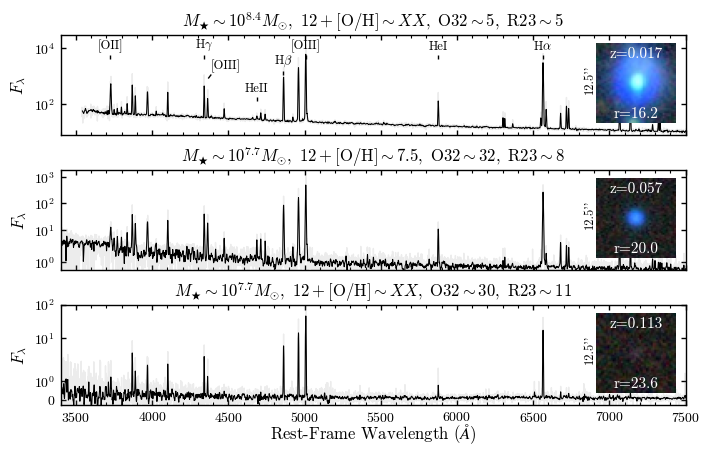

In [215]:
make_spectra_panel_sample([39633358820476651, 39627787190929393, 39633495579954230], "extreme_o32", main_cat, wave_min=3400, wave_max=7500,
                              save_folder="/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/example_spec/", lims=None)


## star formation + Halpha HW + mass-metallicity  plot

In [10]:
import cmasher as cmr

# cmap = cmr.gothic_r.copy()
# cmap.set_under(alpha=0.)

In [11]:
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
base = cmr.gothic_r
# skip the first ~20% of the colormap (the white part)
new_colors = base(np.linspace(0.05, 1.0, 256))
cmap = mcolors.ListedColormap(new_colors)
cmap.set_bad(alpha=0)  # empty bins transparent


In [12]:
main_sfr = main[ (main["DWARF_MASKBIT"] == 0)  ]
fastspec_sfr = fastspec[ (main["DWARF_MASKBIT"] == 0) ]
spec_derived_sfr = spec_derived[ (main["DWARF_MASKBIT"] == 0) ]



In [15]:
elg_mask = (main_sfr["IS_ELG"] ==  True)
no_elg_mask = (main_sfr["IS_ELG"] !=  True) & (main_sfr["IS_OTHER"] != True)
bgsb_mask = (main_sfr["IS_BGS_BRIGHT"] == True)


In [23]:
fiber_ssfr = spec_derived_sfr["LOG_HALPHA_SFR_FIBER"].data - spec_derived_sfr["LOG_MSTAR_24_FIBER"].data

In [24]:
# Brinchmann et al. 2004 — digitized from figure
# x: log10(M*/Msun)
# y: log10(SFR / Msun/yr)  [check axis label of original figure]

# logM_brinchmann04 = np.array([
#     6.522305403710764, 6.65540139627072, 6.7946918146890365, 6.9214587199589275,
#     7.060850134451023, 7.187633872399877, 7.314400777669768, 7.4600202833781495,
#     7.593065777901217, 7.726178603140136, 7.859224097663203, 7.979712413679918,
#     8.119019664777198, 8.258394246590331, 8.391456573792361, 8.530831155605492,
#     8.651268973585317, 8.790660388077413, 8.936330391822684, 9.069359053666789,
#     9.202404548189856, 9.348074551935127, 9.481170544495082, 9.620477795592363,
#     9.759835544726531, 9.905522381150766, 10.051141886859149, 10.184153716024289,
#     10.329806887090598, 10.475443225477942, 10.61478414193315, 10.76045414567842,
#     10.899778229454663, 11.045448233199934, 11.165902883858724, 11.298864214986974,
#     11.431589888609746, 11.545395631078176,
# ])

# logSFR_brinchmann04 = np.array([
#     -1.80856615032424, -1.6918988524321117, -1.6603544120555647, -1.543670281484474,
#     -1.4482963224804637, -1.3209739388047956, -1.204289808233705, -1.1727622005361207,
#     -1.0880096619577246, -0.9607041109610197, -0.8759515723826241, -0.727335849818838,
#     -0.685153156337714, -0.6004174504382811, -0.5050266587553072, -0.42029095285587426,
#     -0.30358998960582095, -0.20821603060181015, -0.14477366359049437, -0.07065937811667533,
#     0.014093160461720267, 0.07753552747303649, 0.19420282536516398, 0.23638551884628844,
#     0.31048297164114436, 0.3845635917570376, 0.41609119945462125, 0.47956723182386307,
#     0.5323713457306016, 0.5745372065327627, 0.6379964062230417, 0.7014387732343574,
#     0.7542597198200587, 0.8177020868313745, 0.9450413031860054, 0.9766025762415156,
#     0.8592283058329442, 0.7844575458795706,
# ])

# ax[0].plot( logM_brinchmann04, logSFR_brinchmann04 - logM_brinchmann04,color="k",lw=1.5,ls="-" )


In [25]:

def add_corner_cbar(ax_parent, mappable):
    """Put a small horizontal colorbar in the bottom-left corner of ax_parent."""
    fig = ax_parent.figure
    
    # Get the TRUE position from the Divider locator
    renderer = fig.canvas.get_renderer()
    bbox = ax_parent.get_axes_locator()(ax_parent, renderer)
    
    x0, y0, w, h = 0.1, 0.125, 0.4, 0.04  # axes fraction
    
    cax = fig.add_axes([
        bbox.x0 + x0 * bbox.width,
        bbox.y0 + y0 * bbox.height,
        w * bbox.width,
        h * bbox.height,
    ])
    cbar = plt.colorbar(mappable, cax=cax, orientation="horizontal")
    cbar.ax.tick_params(pad=3)
    cbar.minorticks_on()   # adds a sensible minor locator
    return cbar


/global/common/software/desi/perlmutter/desiconda/20260227-2.3.1/conda/lib/python3.13/site-packages/scipy/signal/_signaltools.py:1783: RuntimeWarning: divide by zero encountered in divide
  res *= (1 - noise / lVar)
/global/common/software/desi/perlmutter/desiconda/20260227-2.3.1/conda/lib/python3.13/site-packages/scipy/signal/_signaltools.py:1783: RuntimeWarning: invalid value encountered in multiply
  res *= (1 - noise / lVar)
/global/u1/v/virajvm/DESI2_LOWZ/desi_dwarfs/code/plot_style.py:176: UserWarning: Log scale: values of z <= 0 have been masked
  cs = ax.contour(X, Y, H, linewidths=3*np.array([1.0,0.75, 0.5, 0.25])[::-1]*lw_scale, colors=color, levels = sorted(lvls),
/tmp/ipykernel_1733852/2794925718.py:83: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  ax[0].scatter(float(main_sfr[main_sfr["TARGETID"] ==

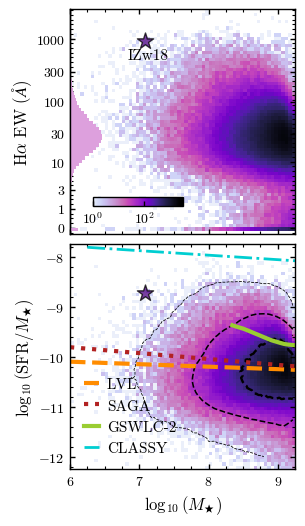

In [27]:

fig,ax = make_subplots(ncol=1,nrow=2,plot_size=2.25,return_fig=True,
                      col_spacing=[MARGIN_LABEL-0.2, MARGIN_PAD],
                      row_spacing=[MARGIN_LABEL-0.35, MARGIN_SHARED, MARGIN_PAD])


hist_nbins = 65
cont_nbins = 100

######

ax[0].hist2d( main_sfr["LOG_MSTAR_M24"][no_elg_mask], fiber_ssfr[no_elg_mask], 
            range=( (6,9.25), (-12.25,-7.75) ), 
          norm=LogNorm(vmin=1,vmax=3000),bins=hist_nbins, cmap = cmap, rasterized=True )

plot_2d_dist(main_sfr["LOG_MSTAR_M24"][no_elg_mask], fiber_ssfr[no_elg_mask], cont_nbins, cont_nbins, 
                cmin=1.e-4, cmax=1.0, smooth=10, clevs=[0, 0.68,0.95,0.997],ax=ax[0], bounds= np.array([ 6,9.25,-12,-8]),
            cmap = make_cmap("darkblue"), color = "k", filled=False, label = None,cmap_alpha=1, lw_scale=.75,
            alternating_contours=False)

##put some other relations on top!
mstar_grid = np.linspace(6,11,50)

# Salim et al. 2018 — digitized from figure

#this is from SED fitting
logM_salim18 = np.array([
    8.344525547445254, 8.395591123618562, 8.445378594670654, 8.495166065722744,
    8.544953536774836, 8.594741007826928, 8.64452847887902, 8.694315949931111,
    8.744103420983203, 8.793890892035293, 8.843678363087385, 8.893465834139477,
    8.943253305191568, 8.99304077624366, 9.042828247295752, 9.092615718347844,
    9.142403189399936, 9.192190660452027, 9.24197813150412, 9.29176560255621,
    9.341553073608301, 9.391340544660393, 9.441128015712485, 9.490915486764576,
    9.540702957816668, 9.590490428868758, 9.64027789992085, 9.690065370972942,
    9.739852842025034, 9.789640313077125, 9.839427784129217, 9.889215255181309,
    9.9390027262334, 9.988790197285493, 10.038577668337584, 10.088365139389674,
    10.138152610441766, 10.187940081493858, 10.23772755254595, 10.287515023598042,
    10.337302494650134, 10.387089965702224, 10.436877436754315, 10.486664907806407,
    10.536452378858499, 10.58623984991059, 10.636027320962683, 10.685814792014774,
    10.735602263066866, 10.785389734118958, 10.83517720517105, 10.88496467622314,
    10.934752147275232, 10.984539618327323, 11.034327089379415, 11.084114560431507,
    11.133902031483597, 11.183689502535689, 11.23347697358778, 11.283264444639872,
    11.333051915691964, 11.382839386744056, 11.432626857796148, 11.48241432884824,
])

logsSFR_salim18 = np.array([
    -9.371769383697814, -9.396945091045549, -9.41690746357924, -9.436169401988941,
    -9.463136115762525, -9.492204131908077, -9.520571713929638, -9.5489392959512,
    -9.577657095034755, -9.606725111180307, -9.635442910263864, -9.66416070934742,
    -9.686574601315074, -9.706536973848765, -9.727199780506446, -9.74576128479216,
    -9.756968230775986, -9.763622354953883, -9.77027647913178, -9.779031905681645,
    -9.791989936975446, -9.801095580587305, -9.808099921827196, -9.818606433687034,
    -9.82666142611291, -9.831914682042829, -9.841370542716682, -9.85642987638245,
    -9.869037690614256, -9.869738124738245, -9.873590512420185, -9.879544202474094,
    -9.893903102015871, -9.912114389239589, -9.930325676463308, -9.948536963687026,
    -9.966748250910745, -9.984609321072469, -10.003170825358183, -10.020681678457912,
    -10.037492097433653, -10.053602082285403, -10.069361850075161, -10.085471834926912,
    -10.100531168592678, -10.114539851072463, -10.12889875061424, -10.142907433094024,
    -10.16251958856572, -10.185633914657364, -10.206997155439034, -10.229761264468682,
    -10.251124505250353, -10.272137528970028, -10.293500769751697, -10.314513793471374,
    -10.338328553687004, -10.363193965088621, -10.388059376490236, -10.412924787891853,
    -10.438840850479451, -10.465457347191041, -10.491723626840635, -10.517639689428234,
])

#this is from SALIM 2018!

##This is from SAGA IV!
# -0.20164403469730652 - 10.09036823569727 * ( (-0.20164403469730652 - ( -3.8512359160889975) ) / ( 10.09036823569727  -  5.953858031699896 ) )

#LVL SEDs this is from the LVL FUV SFR, they assume kroupa imf
log_SFR = 0.95*mstar_grid - 9.8
ax[0].plot( mstar_grid, log_SFR - mstar_grid,ls="--",color="darkorange", lw=3, label = "LVL" )

ax[0].plot(mstar_grid, 0.8822*mstar_grid - 9.1040 - mstar_grid, color="firebrick",ls="dotted",lw=3, label = "SAGA")

ax[0].plot( logM_salim18, logsSFR_salim18,lw=3,ls="-",color="yellowgreen", label = "GSWLC-2" )

logm_grid =  np.linspace(6.25,9.25,100)
logSFR_classy = 0.91*logm_grid - 7.25
logSSFR_classy = logSFR_classy - logm_grid

ax[0].plot( logm_grid, logSSFR_classy,lw=2,ls="-.",color="darkturquoise", label = "CLASSY" )

ax[0].scatter(float(main_sfr[main_sfr["TARGETID"] == izw18_tgid]["LOG_MSTAR_M24"]),
              fiber_ssfr[fastspec_sfr["TARGETID"] ==izw18_tgid],
             marker="*",edgecolor="k",facecolor="#4B0082", s=150, alpha=0.75)




#########################################

ax[0].legend(ncol=1,loc="lower left",
            handlelength=1,handletextpad=0.5, columnspacing=0.8)

ax[0].set_xlim([6,9.25])
ax[0].set_ylim([-12.25,-7.75])
ax[0].set_xlabel(r"$\log_{10}(M_{\bigstar})$")
ax[0].set_ylabel(r"$\log_{10}(\mathrm{SFR} / M_{\bigstar} )$")

# ax[0].text(6.2,-11.7,
#            r"$\mathrm{SNR}(\mathrm{EW}, \mathrm{H}\alpha, \mathrm{H}\beta) > 3$")


###############
###############
###############
###############

h, xedges, yedges, im = ax[1].hist2d( main_sfr["LOG_MSTAR_M24"][no_elg_mask], np.log10(fastspec_sfr["HALPHA_EW"][no_elg_mask]+1), 
            range=( (6,9.25), (-0.1,np.log10(3000)) ), 
          norm=LogNorm(vmin=1,vmax=3000),bins=hist_nbins, cmap = cmap, rasterized=True )

add_corner_cbar(ax[1], im)


from matplotlib.ticker import FuncFormatter

ax[1].set_ylim([-0.1,np.log10(3000)])

# Choose physical EW values you want shown
ew_ticks = [0, 1, 3, 10, 30, 100, 300, 1000]
ax[1].set_yticks([np.log10(v + 1) for v in ew_ticks])
ax[1].set_yticklabels([str(v) for v in ew_ticks])

ax[1].set_ylabel(r"H$\alpha$ EW ($\AA$)")

ax[1].scatter(float(main_sfr[main_sfr["TARGETID"] == izw18_tgid]["LOG_MSTAR_M24"]),
              np.log10(float(fastspec_sfr[fastspec_sfr["TARGETID"] ==izw18_tgid]["HALPHA_EW"])),
             marker="*",edgecolor="k",facecolor="#4B0082", s=150, alpha=0.75)

ax[1].text(float(main_sfr[main_sfr["TARGETID"] == izw18_tgid]["LOG_MSTAR_M24"]) - 0.25,
              np.log10(float(fastspec_sfr[fastspec_sfr["TARGETID"] ==izw18_tgid]["HALPHA_EW"])) - 0.3,
           "IZw18",color="k")

# plot_2d_dist(main_sfr["LOG_MSTAR_M24"][no_elg_mask], np.log10(fastspec_sfr["HALPHA_EW"][no_elg_mask]+1), cont_nbins+50, cont_nbins+50, 
#                 cmin=1.e-4, cmax=1.0, smooth=10, clevs=[0, 0.68,0.95,0.997],ax=ax[1], bounds= np.array([ 6,9.25,-0.05,np.log10(2000)]),
#             cmap = make_cmap("darkblue"), color = "k", filled=False, label = None,cmap_alpha=1, lw_scale=.75,
#             alternating_contours=False)


##we need to add a color bar here!!


#--- 

from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# Create an inset on the left side of ax[1], inside the panel
ax_marg = inset_axes(
    ax[1],
    width="15%",        # horizontal extent — tweak to taste (10–20%)
    height="100%",      # full vertical extent to match the y-axis
    loc="lower left",
    borderpad=0,
)

# Compute the histogram in the same y-coordinate as the main panel: log10(EW+1)
y_vals = np.log10(fastspec_sfr["HALPHA_EW"][no_elg_mask] + 1)
y_vals = y_vals[(y_vals >= -0.05) & (y_vals <= np.log10(1000))]   # match panel range

ax_marg.hist(
    y_vals,
    bins=hist_nbins,
    range=(-0.05, np.log10(2000)),
    orientation="horizontal",
    color="plum",
    edgecolor="none",
    rasterized=True
)

# Match y-limits to the main panel exactly
ax_marg.set_ylim(ax[1].get_ylim())

# Strip ticks/labels — the main panel already shows them
ax_marg.set_yticks([])
ax_marg.set_xticks([])

# Optional: make the background transparent so the 2D hist shows through
ax_marg.patch.set_alpha(0.0)

# Optional: thin or remove spines for a cleaner look
for s in ["top", "right", "bottom"]:
    ax_marg.spines[s].set_visible(False)

    
# for i in range():
ax[1].set_xticklabels([])

from matplotlib.ticker import MultipleLocator

for a in ax:
    a.xaxis.set_minor_locator(MultipleLocator(0.25))
    a.yaxis.labelpad = 2 
    # 
plt.savefig("/global/homes/v/virajvm/DESI2_LOWZ/quenched_fracs_nbs/paper_plots/desi_dwarfs_phys_props.pdf")

plt.show()

## Mass - metallicity relation 

Need to compute the direct metallicitiy 

In [25]:
# import sys
# !{sys.executable} -m pip install ultranest

In [71]:
te_mask = line_snr_mask(fastspec_sfr, 
              line_names = ["HALPHA","HBETA","HGAMMA", "OIII_4363","OIII_5007","OII_3726","OII_3729"], snr_val=5,
              min_lines = 7, line_flux_type="FLUX"
             )

print(np.sum(te_mask))


3608


In [72]:
fastspec_te_zmet = fastspec_sfr[te_mask]
spec_derived_te_zmet = spec_derived_sfr[te_mask]
main_te_zmet = main_sfr[te_mask]



In [73]:
spec_derived_te_zmet[spec_derived_te_zmet["TARGETID"]== izw18_tgid]

TARGETID,LOG_SFR_HALPHA,LOG_SFR_HALPHA_ERR,LOG_MSTAR_24_FIBER,LOG_HALPHA_SFR_FIBER,Z_GAS_R23_N2,DELTA_MAG_G_BASS2DECAM,DELTA_MAG_R_BASS2DECAM,DELTA_MAG_G_NEB,DELTA_MAG_R_NEB,DELTA_MAG_G_DECAM2SDSS,DELTA_MAG_R_DECAM2SDSS,DELTA_MAG_G_KCORR,DELTA_MAG_R_KCORR,TE_NE_OII,TE_NE_OII_LO,TE_NE_OII_HI,TE_NE_OII_ERR,TE_T_OIII,TE_T_OIII_LO,TE_T_OIII_HI,TE_T_OIII_ERR,TE_AV,TE_AV_LO,TE_AV_HI,TE_AV_ERR,TE_LOG_O2_ABUND,TE_LOG_O2_ABUND_LO,TE_LOG_O2_ABUND_HI,TE_LOG_O2_ABUND_ERR,TE_LOG_O3_ABUND,TE_LOG_O3_ABUND_LO,TE_LOG_O3_ABUND_HI,TE_LOG_O3_ABUND_ERR,TE_12_LOG_OH,TE_12_LOG_OH_LO,TE_12_LOG_OH_HI,TE_12_LOG_OH_ERR,TE_N_RATIOS,TE_FIT_SUCCESS,TE_CHI2_AV,TE_CHI2_AV_ML,TE_AV_ML,TE_ESS,TE_LOGZ,TE_LOGZERR,MAG_G_DECAM_MODEL_NOEMI,MAG_R_DECAM_MODEL_NOEMI,MAG_G_DECAM_MODEL_WEMI,MAG_R_DECAM_MODEL_WEMI,MAG_G_BASS_MODEL_WEMI,MAG_R_BASS_MODEL_WEMI,MAG_G_SDSS_MODEL_NOEMI,MAG_R_SDSS_MODEL_NOEMI,MAG_G_SDSS_Z0_MODEL_NOEMI,MAG_R_SDSS_Z0_MODEL_NOEMI
,,,,,,mag,mag,mag,mag,mag,mag,mag,mag,1 / cm3,1 / cm3,1 / cm3,1 / cm3,K,K,K,K,mag,mag,mag,mag,,,,,,,,,,,,,,,,,mag,,,,mag,mag,mag,mag,mag,mag,mag,mag,mag,mag
int64,float64,float64,float32,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int32,bool,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
39633324993414901,-1.4889915726188157,0.012769571979409576,5.9752264,-2.800671440837857,7.353865567817396,-0.004230249873291569,0.009584871294073594,0.4914173277338385,0.5795577993627319,0.001241379158376077,0.00068105562387899,0.0023748945575690072,0.0029386571726561783,477.1185440413877,477.1185440413877,477.1185440413877,0.0,19775.83747691435,19775.83747691435,19775.83747691435,0.0,0.0998311527454489,0.0998311527454489,0.0998311527454489,0.0,-5.565015765709534,-5.565015765709534,-5.565015765709534,0.0,-5.0080582253482815,-5.0080582253482815,-5.0080582253482815,0.0,7.098254789674568,7.098254789674568,7.098254789674568,0.0,6,True,56.22796369770068,56.22796369770068,0.0998311527454489,1.0198354425203129,-62.175742270482075,0.9981617392213832,19.59175893944536,19.604043838042692,19.10034161171152,19.02448603867996,19.104571861584812,19.014901167385887,19.593000318603735,19.60472489366657,19.595371637609674,19.60761367920758


In [74]:
# # Fast MLE for diagnostics or quick passes
# results_mle = compute_direct_metallicities(my_table, method='mle', verbose=True)

# Apply the Scholte+2026 quality cut on output
# good = (results['twelve_log_OH_hi'] - results['twelve_log_OH_lo']) < 0.6

/tmp/ipykernel_1854481/3772256715.py:140: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  ax[0].scatter(float(main_sfr[main_sfr["TARGETID"] == izw18_tgid]["LOG_MSTAR_M24"]),
/tmp/ipykernel_1854481/3772256715.py:141: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  float(sui26_tab[sui26_tab["TARGETID"] ==izw18_tgid]["O_ABUNDANCE"]),
/tmp/ipykernel_1854481/3772256715.py:144: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  ax[0].text(float(main_sfr[main_sfr["TARGETID"] == iz

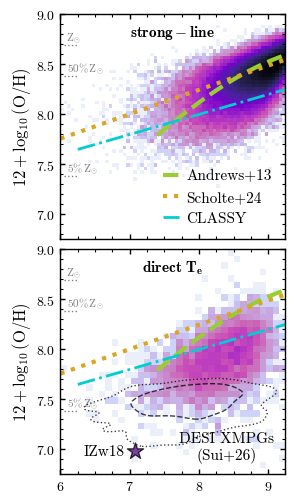

In [84]:

fig,ax = make_subplots(ncol=1,nrow=2,plot_size=2.25,return_fig=True,
                      col_spacing=[MARGIN_LABEL-0.2, MARGIN_PAD],
                      row_spacing=[MARGIN_LABEL-0.35, MARGIN_SHARED, MARGIN_PAD])


hist_nbins = 65
cont_nbins = 100

ax[1].hist2d(main_sfr["LOG_MSTAR_M24"][no_elg_mask],  spec_derived_sfr["Z_GAS_R23_N2"][no_elg_mask], range= ( (6,9.25), (6.75,9) ),
            norm=LogNorm(vmin=1,vmax=3000),bins=hist_nbins, cmap = cmap, rasterized=True)

#mzr model from brett andrews et al. see Equation 5 and table 4
for axi in ax:
    mstar_grid = np.linspace(7.4,10.5,100)
    axi.plot(mstar_grid, 8.798 - np.log10( 1 + (10**8.901 / 10**mstar_grid)**0.640 ), color="yellowgreen",lw=3,ls="--",
               label = "Andrews+13") 

##add scholte relation
def scholte24_rel(mstar):
    '''
    This is data from the table 1 in scholte et al. paper
    '''
    Z0=8.854
    gamma= 0.2439
    beta = 1.20
    m0 = 10**(10.49)
    return Z0 - (gamma/beta)*np.log10( 1 + (mstar/m0)**(-beta) )

for axi in ax:
    mstar_grid = np.linspace(6,10.5,100)
    axi.plot(mstar_grid, scholte24_rel(10**mstar_grid), color="goldenrod",lw=3,ls="dotted", label = "Scholte+24") 


mstar_grid = np.linspace(6.25,10,100)
classy_zmet = 0.20*mstar_grid + 6.40

for axi in ax:
    axi.plot(mstar_grid, classy_zmet, lw=2,ls="-.",color="darkturquoise", label = "CLASSY") 

## add direct metallicities from the Sui et al sample?
sui26_tab = Table.read("/global/homes/v/virajvm/DESI2_LOWZ/desi_dwarfs/data/table1.fits")

# Filter main_sfr to only galaxies that appear in sui26_tab
mask = np.isin(main_sfr["TARGETID"].data, sui26_tab["TARGETID"].data)
main_zpoor_tab = main_sfr[mask]

# Now align the two tables by TARGETID so the rows correspond
# Build an index mapping: for each row in main_zpoor_tab, find its row in sui26_tab
sort_idx = np.argsort(sui26_tab["TARGETID"].data)
matched_idx = sort_idx[np.searchsorted(
    sui26_tab["TARGETID"].data[sort_idx],
    main_zpoor_tab["TARGETID"].data
)]

logM = main_zpoor_tab["LOG_MSTAR_M24"]
o_abund = sui26_tab["O_ABUNDANCE"][matched_idx]

# print(len(logM))

# ax[0].scatter(logM, o_abund,
#               s=20, marker="o",
#               facecolor="none", edgecolor="orchid", linewidths=1.0,
#               zorder=5)

# --- compute KDE ---
xy = np.vstack([logM, o_abund])
kde = gaussian_kde(xy, bw_method='scott')

# grid covering your data range (with some padding)
pad = 0.1
x_min, x_max = logM.min() - pad, logM.max() + pad
y_min, y_max = o_abund.min() - pad, o_abund.max() + pad

xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))
zz = kde(np.vstack([xx.ravel(), yy.ravel()])).reshape(xx.shape)

# --- find density levels corresponding to 1σ and 2σ ---
# i.e. the iso-density line that encloses ~68% and ~95% of the probability mass
def density_level(kde_values, fraction):
    """Return the density threshold enclosing `fraction` of the total mass."""
    flat = np.sort(kde_values.ravel())[::-1]          # high → low
    cumsum = np.cumsum(flat) / flat.sum()
    idx = np.searchsorted(cumsum, fraction)
    return flat[min(idx, len(flat) - 1)]

level_1s = density_level(zz, 0.683)   # ~68%  → 1σ
level_2s = density_level(zz, 0.954)   # ~95%  → 2σ

# ax[0].contourf(xx, yy, zz,
#                levels=[level_2s, level_1s, zz.max()],
#                colors=["orchid", "mediumorchid"],   # light → dark blue
#                zorder=3,alpha=0.5)

ax[0].text(8.4,6.9,"DESI XMPGs\n(Sui+26)",color="k",ha="center")

# contour lines mediumvioletred
cs = ax[0].contour(xx, yy, zz,
                   levels=[level_2s, level_1s],
                   colors=["k", "k"],
                   linewidths=1,linestyles=["dotted","--"],
                   zorder=4,alpha=0.75)

## add solar, 50% solar and 5% solar or something?
solar = 8.69
metallicities = {
    r"5%$\,$Z$_{\!\odot}$":  solar + np.log10(0.05),   # 7.39
    r"50%$\,$Z$_{\!\odot}$": solar + np.log10(0.50),   # 8.39
    r"Z$_{\!\odot}$":     solar,                     # 8.69
}

xpos_vals = [27, 31, 15]

for axi in ax:
    index=0
    for label, val in metallicities.items():
        # only draw if within the y-axis range
        if 6.75 <= val <= 9.0:
            # ax[2].axhline(val, color="gray", lw=0.8, ls=":", alpha=0.6, zorder=1)
    
            axi.plot([6.05, 6.25], [val, val],   # short line at x=x_min edge
               color="gray", lw=1, solid_capstyle="butt",
               clip_on=False, zorder=6, ls =":")
            
            axi.annotate(label,
                           xy=(0, val),                    # axes coords x, data coords y
                           xycoords=("axes fraction", "data"),
                           xytext=(xpos_vals[index], 5),                 # nudge left of spine
                           textcoords="offset points",
                           ha="right", va="center",
                           fontsize=8, color="gray")
    
            index += 1


ax[0].hist2d(main_te_zmet["LOG_MSTAR_M24"].data,  spec_derived_te_zmet["TE_12_LOG_OH"].data, range= ( (6,9.25), (6.75,9) ),
            norm=LogNorm(vmin=1,vmax=3000),bins=35, cmap = cmap, rasterized=True, zorder=0)

    
ax[0].scatter(float(main_sfr[main_sfr["TARGETID"] == izw18_tgid]["LOG_MSTAR_M24"]),
              float(sui26_tab[sui26_tab["TARGETID"] ==izw18_tgid]["O_ABUNDANCE"]),
             marker="*",edgecolor="k",facecolor="#4B0082", s=150,alpha=0.75, zorder=1)

ax[0].text(float(main_sfr[main_sfr["TARGETID"] == izw18_tgid]["LOG_MSTAR_M24"]) - 0.75,
              float(sui26_tab[sui26_tab["TARGETID"] ==izw18_tgid]["O_ABUNDANCE"]) - 0.05,
           "IZw18",color="k", zorder=1)


ax[1].legend(loc="lower right", handlelength=1, handletextpad=0.5, columnspacing=0.8)

ax[1].set_xticklabels([])

for axi in ax:
    axi.set_ylim([6.75,9])
    axi.set_xlim([6,9.25])
    
    axi.set_ylabel(r"$12 + \log_{10}(\mathrm{O}/\mathrm{H})$")

xpos=0.5
ypos=0.90

ax[0].text(xpos,ypos,r"$\mathbf{direct \,\, T_e}$",transform=ax[0].transAxes,ha="center" )

ax[1].text(xpos,ypos,r"$\mathbf{strong-line}$",transform=ax[1].transAxes,ha="center" )


from matplotlib.ticker import MultipleLocator

for a in ax:
    a.xaxis.set_minor_locator(MultipleLocator(0.25))
    a.yaxis.labelpad = 2 
    
plt.savefig("/global/homes/v/virajvm/DESI2_LOWZ/quenched_fracs_nbs/paper_plots/desi_dwarfs_mass_metal.pdf")

plt.show()

In [53]:
# sui26_tab["TARGETID"]
from tqdm.notebook import trange

sui26_matched_zmets = []
cat_matched_zmets = []

for i in trange(len(spec_derived_te_zmet)):
    tgid_i = spec_derived_te_zmet["TARGETID"].data[i]

    #if it exists in sui26 table
    matched = (sui26_tab["TARGETID"] == tgid_i)

    if np.sum(matched) == 0:
        pass
    else:
        sui26_matched_zmets.append( float(sui26_tab[sui26_tab["TARGETID"] == tgid_i]["O_ABUNDANCE"]) )

        cat_matched_zmets.append( float(spec_derived_te_zmet[spec_derived_te_zmet["TARGETID"] == tgid_i]["TE_12_LOG_OH"] ) )
        

            
        


  0%|          | 0/3608 [00:00<?, ?it/s]

/tmp/ipykernel_1854481/2852291338.py:16: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  sui26_matched_zmets.append( float(sui26_tab[sui26_tab["TARGETID"] == tgid_i]["O_ABUNDANCE"]) )


## MORPHOLOGY PLOT!

We can plot the NSC on this!

In [28]:
main_bgsb = main_sfr[(main_sfr["IS_ELG"] != True) & (main_sfr["IS_OTHER"] != True)]


In [29]:
from astropy import units as u

D_A = (main_bgsb["LUMI_DIST_MPC"].data * u.Mpc) / (1 + main_bgsb["Z_CMB"].data)**2
r12_kpc = (D_A * (main_bgsb["R50_R"] * u.arcsec).to(u.rad).value).to(u.kpc).value

In [30]:
np.min(r12_kpc),np.max(r12_kpc)

(np.float64(0.0), np.float64(20.52820197569264))

In [31]:
import numpy as np
import matplotlib.pyplot as plt


# def get_binned(x,y,bin_size =  0.5):
#     m = np.isfinite(x) & np.isfinite(y)
#     x, y = x[m], y[m]

#     # --- bins ---
#     edges = np.arange(5.0, 9.5 + 1e-9, bin_size)        # adjust step as you like
#     centers = 0.5 * (edges[:-1] + edges[1:])
#     nbins = len(centers)
    
#     med = np.full(nbins, np.nan)
#     lo  = np.full(nbins, np.nan)
#     hi  = np.full(nbins, np.nan)
    
#     for k in range(nbins):
#         in_bin = (x >= edges[k]) & (x < edges[k+1] if k < nbins - 1 else x <= edges[k+1])
#         if in_bin.sum() >= 10:
#             med[k] = np.median(y[in_bin])
#             lo[k], hi[k] = np.percentile(y[in_bin], [2.275, 97.725])  # ±2σ-equivalent
    
#     ok = np.isfinite(med)
    
#     return centers[ok], med[ok], lo[ok], hi[ok] 

import numpy as np

def get_binned(x, y, sigma_mode="percentile_2sigma"):
    """
    Binned median + envelope.

    sigma_mode:
      "percentile_2sigma" -- direct 2.275/97.725 percentiles (old behavior)
      "double_1sigma"     -- take 16/84 percentiles, double the half-widths
                             about the median (much more stable)
    """
    m = np.isfinite(x) & np.isfinite(y)
    x, y = x[m], y[m]

    edges = np.arange(5.0, 9.5 + 1e-9, 0.5)
    centers = 0.5 * (edges[:-1] + edges[1:])
    nbins = len(centers)

    med = np.full(nbins, np.nan)
    lo  = np.full(nbins, np.nan)
    hi  = np.full(nbins, np.nan)

    for k in range(nbins):
        in_bin = (x >= edges[k]) & (x < edges[k+1] if k < nbins - 1 else x <= edges[k+1])
        if in_bin.sum() < 25:
            continue

        yb = y[in_bin]
        med[k] = np.median(yb)

        if sigma_mode == "percentile_2sigma":
            lo[k], hi[k] = np.percentile(yb, [2.275, 97.725])
        elif sigma_mode == "double_1sigma":
            p16, p84 = np.percentile(yb, [15.865, 84.135])
            # Distance from the median to each 1σ percentile, doubled
            lo[k] = med[k] - 2.0 * (med[k] - p16)
            hi[k] = med[k] + 2.0 * (p84 - med[k])
        else:
            raise ValueError(f"unknown sigma_mode: {sigma_mode}")

    ok = np.isfinite(med)
    return centers[ok], med[ok], lo[ok], hi[ok]

/tmp/ipykernel_1733852/338425022.py:9: RuntimeWarning: divide by zero encountered in log10
  ax[1].hist2d(main_bgsb["LOG_MSTAR_M24"][bad_mask],  np.log10(r12_kpc[bad_mask]), range= ( (6,9.25), (-2.5,1.6) ),


verion v1.1.0


/tmp/ipykernel_1733852/338425022.py:40: RuntimeWarning: divide by zero encountered in log10
  y = np.log10(np.array(dwarf_lf["rhalf_sph_physical"]) / 1e3)   # log10(r_half / kpc)
/tmp/ipykernel_1733852/338425022.py:115: RuntimeWarning: divide by zero encountered in log10
  ax[1].scatter(main_ucd["LOG_MSTAR_M24"],np.log10(main_ucd["r12_kpc"]), marker="x",color="darkmagenta",s=20,zorder=5 )
/tmp/ipykernel_1733852/338425022.py:149: RuntimeWarning: divide by zero encountered in log10
  mu_r = mag_v + 2.5*np.log10( 2*np.pi * (main_bgsb["R50_R"].data**2) )
/global/common/software/desi/perlmutter/desiconda/20260227-2.3.1/conda/lib/python3.13/site-packages/scipy/signal/_signaltools.py:1783: RuntimeWarning: divide by zero encountered in divide
  res *= (1 - noise / lVar)
/global/common/software/desi/perlmutter/desiconda/20260227-2.3.1/conda/lib/python3.13/site-packages/scipy/signal/_signaltools.py:1783: RuntimeWarning: invalid value encountered in multiply
  res *= (1 - noise / lVar)
/global/u1

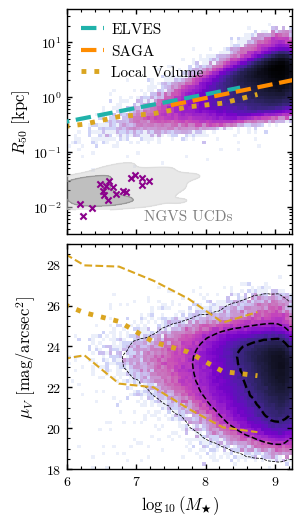

In [32]:
fig,ax = make_subplots(ncol=1,nrow=2,plot_size=2.25,return_fig=True,
                      col_spacing=[MARGIN_LABEL-0.35, MARGIN_PAD],
                      row_spacing=[MARGIN_LABEL-0.4, MARGIN_SHARED, MARGIN_PAD])


bad_tgids = [39627793348170704, 39627883991269971, 39633016523332414, 39627805201271100]
bad_mask = ~np.isin(main_bgsb["TARGETID"], bad_tgids)  # adjust column name if different

ax[1].hist2d(main_bgsb["LOG_MSTAR_M24"][bad_mask],  np.log10(r12_kpc[bad_mask]), range= ( (6,9.25), (-2.5,1.6) ),
            norm=LogNorm(vmin=1,vmax=3000),bins=hist_nbins, cmap = cmap, rasterized=True )


#################################
mstar_grid = np.linspace(5.5,8.5)
log_r12_c21 = 0.247*mstar_grid + 1.071 - 3
ax[1].plot(mstar_grid, log_r12_c21, color = "lightseagreen",lw=3,zorder=10,alpha=1,ls="--", label = "ELVES")

#plot the line from the SAGA size-mass paper
mstar_grid = np.linspace(7.5,9.5)
log_r12_saga = 0.26*mstar_grid - 2.10
ax[1].plot(mstar_grid, log_r12_saga, color = "darkorange",lw=3,zorder=10,alpha=1,ls="--", label = "SAGA")

import astropy.table as table
# loads the current catalog from the release page (recommended)
version_number_string = table.Table.read('https://raw.githubusercontent.com/apace7/local_volume_database/main/code/release_version.txt', format='ascii.fast_no_header')['col1'][0]

print("verion", version_number_string)
## load combined table
comb_all = table.Table.read('https://github.com/apace7/local_volume_database/releases/download/'+version_number_string+'/comb_all.csv')

#combining all the dwarfs!!
dsph_lf = comb_all[comb_all['table'] == 'dwarf_local_field']
dsph_mw = comb_all[comb_all['table'] == 'dwarf_mw']
dsph_m31 = comb_all[comb_all['table'] == 'dwarf_m31']
dsph_dst = comb_all[comb_all['table'] == 'dwarf_local_field_distant']
dwarf_lf = vstack([dsph_lf,dsph_mw, dsph_m31, dsph_dst])

# --- data ---
x = np.array(dwarf_lf["mass_stellar"])
y = np.log10(np.array(dwarf_lf["rhalf_sph_physical"]) / 1e3)   # log10(r_half / kpc)

# ax[0].scatter(dwarf_lf["mass_stellar"].data, np.log10(dwarf_lf["rhalf_sph_physical"].data/1e3),
#               facecolor="silver",edgecolor="k",lw=0.5,s=20, marker="s", label = "Local Volume" )

lv_cents, lv_med, _, _ = get_binned(x,y)

ax[1].plot(lv_cents, lv_med, color="goldenrod",lw=3.5,ls="dotted", label = "Local Volume")


#loading the ucd dataset from virgo
from astropy.io import ascii
table = ascii.read("/global/homes/v/virajvm/DESI2_LOWZ/desi_dwarfs/data/ngvs_ucd_data.txt", format="mrt")

# Stellar mass (log Msun) and half-light radius (pc)
ucd_mstar = table["Mstar"]
ucd_rh_pc = table["rh"]
ucd_rh_logkpc = np.log10(ucd_rh_pc/1e3)
# --- compute KDE ---
xy = np.vstack([ucd_mstar, ucd_rh_logkpc])
kde = gaussian_kde(xy, bw_method='scott')

# grid covering your data range (with some padding)
pad = 0.1
x_min, x_max = ucd_mstar.min() - pad, ucd_mstar.max() + pad
y_min, y_max = ucd_rh_logkpc.min() - pad, ucd_rh_logkpc.max() + pad

xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))
zz = kde(np.vstack([xx.ravel(), yy.ravel()])).reshape(xx.shape)

# --- find density levels corresponding to 1σ and 2σ ---
# i.e. the iso-density line that encloses ~68% and ~95% of the probability mass
def density_level(kde_values, fraction):
    """Return the density threshold enclosing `fraction` of the total mass."""
    flat = np.sort(kde_values.ravel())[::-1]          # high → low
    cumsum = np.cumsum(flat) / flat.sum()
    idx = np.searchsorted(cumsum, fraction)
    return flat[min(idx, len(flat) - 1)]

level_1s = density_level(zz, 0.683)   # ~68%  → 1σ
level_2s = density_level(zz, 0.954)   # ~95%  → 2σ

ax[1].contourf(xx, yy, zz,
               levels=[level_2s, level_1s, zz.max()],
               colors=["lightgrey", "grey"],   # light → dark blue
               zorder=3,alpha=0.5)

ax[1].text(7.75,-2.25,"NGVS UCDs",color="grey",ha="center")

# contour lines
cs = ax[1].contour(xx, yy, zz,
                   levels=[level_2s, level_1s],
                   colors=["lightgrey", "grey"],
                   linewidths=1,
                   zorder=4,alpha=0.5)


#############################


mask = (
    (r12_kpc < 50/1000)
    & (main_bgsb["LOG_MSTAR_M24"] > 6)
    & (main_bgsb["LOG_MSTAR_M24"] < 7.5)
    & (main_bgsb["Z"] < 0.01)
)

# also exclude the flagged TARGETIDs
bad_tgids = [39627793348170704, 39627883991269971, 39633016523332414, 39627805201271100]
mask &= ~np.isin(main_bgsb["TARGETID"], bad_tgids)  # adjust column name if different

main_ucd = main_bgsb[mask]["RA", "DEC", "LOG_MSTAR_M24"]  # astropy Table syntax
main_ucd["r12_kpc"] = r12_kpc[mask]

ax[1].scatter(main_ucd["LOG_MSTAR_M24"],np.log10(main_ucd["r12_kpc"]), marker="x",color="darkmagenta",s=20,zorder=5 )

####

# ax[1].set_xlabel(r"$\log_{10}(M_{\bigstar})$")
ax[1].set_ylabel(r"$R_{50}$ [kpc]", labelpad=1)


from matplotlib.ticker import FuncFormatter, FixedLocator

# Major ticks at integer log values, formatted as scientific notation
def log_to_sci(val, pos):
    return r"$10^{%d}$" % int(val)

ax[1].yaxis.set_major_locator(FixedLocator([-2, -1, 0, 1]))
ax[1].yaxis.set_major_formatter(FuncFormatter(log_to_sci))

# Minor ticks at log-spaced positions within each decade
minor_ticks = []
for decade in range(-3, 2):  # cover a bit beyond your range to be safe
    for n in range(2, 10):
        minor_ticks.append(decade + np.log10(n))
ax[1].yaxis.set_minor_locator(FixedLocator(minor_ticks))

ax[1].legend(ncol=1, handlelength=1.5, handletextpad=0.5, loc = "upper left",columnspacing=0.6)


################################################
################################################
################################################
################################################

mag_v = main_bgsb["MAG_G"].data - 0.5784*(main_bgsb["MAG_G"].data - main_bgsb["MAG_R"].data) - 0.0038

mu_r = mag_v + 2.5*np.log10( 2*np.pi * (main_bgsb["R50_R"].data**2) ) 

ax[0].hist2d(main_bgsb["LOG_MSTAR_M24"][bad_mask],  mu_r[bad_mask], range= ( (6,9.25), (18,29) ),
            norm=LogNorm(vmin=1,vmax=3000),bins=hist_nbins, cmap = cmap, rasterized=True )


## we will plot some contours on it!!
plot_2d_dist(main_bgsb["LOG_MSTAR_M24"][bad_mask], mu_r[bad_mask], hist_nbins, hist_nbins, 
                cmin=1.e-4, cmax=1.0, smooth=5, clevs=[0, 0.68,0.95,0.997],ax=ax[0], bounds= np.array([ 6,9.25,18,29]),
            cmap = make_cmap("darkblue"), color = "k", filled=False, label = None,cmap_alpha=1, lw_scale=.75,
            alternating_contours=False)

from astropy.io import ascii
# Read the Machine-Readable Table. astropy parses the byte-by-byte header
# automatically, so column names, units, and missing-value handling are all
# set up for you.
tbl = ascii.read("/global/homes/v/virajvm/DESI2_LOWZ/desi_dwarfs/data/elves_dwarf_c21.txt", format="mrt")
# The two columns you asked for:
#   logMstar  -- log10(stellar mass / Msun)
#   mu0V      -- V-band CENTRAL surface brightness, mag arcsec^-2
# Recommended cleaning:
#   - drop rows flagged with bad photometry (Bad == 'y')
#   - drop rows where logMstar is masked (missing)
good = (tbl["Bad"].filled("") != "y") #& (~tbl["logMstar"].mask)
tbl_clean = tbl[good]
logMstar = tbl_clean["logMstar"].data
mu0V     = tbl_clean["mu0V"].data

###

x = np.array(dwarf_lf["mass_stellar"])
y = np.array(dwarf_lf["surface_brightness_rhalf"])   # log10(r_half / kpc)

x = np.concatenate([x,logMstar])
y = np.concatenate([y,mu0V])


lv_cents, lv_med, lv_lo, lv_hi = get_binned(x[y > 15],y[y>15], sigma_mode="double_1sigma")

ax[0].plot(lv_cents, lv_med, color="goldenrod",lw=3.5,ls="dotted", label = "Local Volume")

ax[0].plot(lv_cents, lv_lo, color="goldenrod",lw=1.5,ls="--")
ax[0].plot(lv_cents, lv_hi, color="goldenrod",lw=1.5,ls="--")

# ax[1].scatter( dwarf_lf["mass_stellar"].data, dwarf_lf["surface_brightness_rhalf"].data,
#               facecolor="silver",edgecolor="k",lw=0.5,s=20, marker="s", label = "Local Volume" )
# ax[1].scatter(logMstar, mu0V )

ax[0].set_xlabel(r"$\log_{10}(M_{\bigstar})$")
ax[0].set_ylabel(r"$\mu_V$ [mag/arcsec$^2$]", labelpad=6)

##make a plot of sruface brightness in r band vs. stellar mass
##

ax[1].set_xticklabels([])

plt.savefig("/global/homes/v/virajvm/DESI2_LOWZ/quenched_fracs_nbs/paper_plots/desi_dwarfs_size_mass.pdf")

plt.show()


### ba plot

In [328]:
main_ba = main_bgsb[(main_bgsb["R50_R"] > 5) & (main_bgsb["DWARF_MASKBIT"] == 0) & (main_bgsb["Z"] < 0.05)]


In [329]:
import numpy as np

# --- user knobs ---
logm_lo, logm_hi =6, 6.5   # your LOG_MSTAR_M24 range
n_per_bin = 3
rng = np.random.default_rng(42)  # set seed for reproducibility; drop for true random
# ------------------

# Recompute b/a aligned to main_ba (your ba_vals was already this, but redo
# defensively so indices line up even if you re-filter main_ba).
ba = main_ba["SHAPE_PARAMS"].data[:, 0]
logm = main_ba["LOG_MSTAR_M24"].data
ra  = main_ba["RA"].data
dec = main_ba["DEC"].data

# Mass cut
mass_mask = (logm >= logm_lo) & (logm < logm_hi)

# b/a bins of width 0.2
edges = np.arange(0.0, 1.0 + 1e-9, 0.2)   # [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]

for lo, hi in zip(edges[:-1], edges[1:]):
    # include right edge only in the last bin so 1.0 doesn't fall through
    if hi == edges[-1]:
        bin_mask = (ba >= lo) & (ba <= hi)
    else:
        bin_mask = (ba >= lo) & (ba < hi)

    in_bin = np.where(mass_mask & bin_mask)[0]

    print(f"\nb/a in [{lo:.1f}, {hi:.1f}{')' if hi != edges[-1] else ']'}  "
          f"-- {len(in_bin)} objects in mass range")

    if len(in_bin) == 0:
        print("  (none)")
        continue

    pick = rng.choice(in_bin, size=min(n_per_bin, len(in_bin)), replace=False)
    for i in pick:
        print(f"{ra[i]:10.5f}, {dec[i]:+10.5f}")
              # f"b/a={ba[i]:.3f}  logM={logm[i]:.2f}")


b/a in [0.0, 0.2)  -- 0 objects in mass range
  (none)

b/a in [0.2, 0.4)  -- 0 objects in mass range
  (none)

b/a in [0.4, 0.6)  -- 5 objects in mass range
 195.07821,  +29.55133
  44.30841,  -14.11580
 163.15545,  +36.76930

b/a in [0.6, 0.8)  -- 2 objects in mass range
 196.11814,  +36.77719
 196.15231,   -4.45176

b/a in [0.8, 1.0]  -- 0 objects in mass range
  (none)


In [343]:
import os
import numpy as np
import matplotlib.image as mpimg
import requests
from astropy import units as u
from astropy.cosmology import Planck18

# --- bins ---
logm_bins = np.arange(6.0, 9.0 + 1e-9, 0.5)   # mass bins (x-axis)
ba_bins   = np.arange(0.0, 1.0 + 1e-9, 0.2)    # b/a bins  (y-axis)
Nx = len(logm_bins) - 1
Ny = len(ba_bins) - 1

# --- per-mass-bin physical cutout size, in kpc (one value per x-bin) ---
phys_size_kpc_per_xbin = [2.0, 3.0, 5.0, 8.0, 12.0, 18.0]   # length must == Nx
assert len(phys_size_kpc_per_xbin) == Nx, (
    f"phys_size_kpc_per_xbin has length {len(phys_size_kpc_per_xbin)}, expected {Nx}"
)

native_pixscale = 0.262          # Legacy Survey native, arcsec/pix

save_path = "/pscratch/sd/v/virajvm/trash/desi_imgs"
os.makedirs(save_path, exist_ok=True)
session = requests.Session()
overwrite = True

# --- catalog arrays (aligned to main_ba) ---
ba    = main_ba["SHAPE_PARAMS"].data[:, 0]
logm  = main_ba["LOG_MSTAR_M24"].data
ra    = main_ba["RA"].data
dec   = main_ba["DEC"].data
tgid  = main_ba["TARGETID"].data
D_L   = main_ba["LUMI_DIST_MPC"].data * u.Mpc
z_cmb = main_ba["Z_CMB"].data
D_A   = D_L / (1.0 + z_cmb)**2       # angular diameter distance, Mpc

# --- pick one object per (mass, b/a) bin and fetch its cutout ---
images = {}
counts = {}
rng = np.random.default_rng(42)

for i in range(Nx):
    m_lo, m_hi = logm_bins[i], logm_bins[i+1]
    m_mask = (logm >= m_lo) & (logm <= m_hi) if i == Nx - 1 else (logm >= m_lo) & (logm < m_hi)

    # physical cutout size for THIS mass bin
    phys_size_kpc_i = phys_size_kpc_per_xbin[i]

    # angular size (arcsec) per object for this mass bin's target physical size
    theta_arcsec_per_obj = (
        ((phys_size_kpc_i * u.kpc) / D_A.to(u.kpc)) * u.rad
    ).to(u.arcsec).value

    # fixed native pixel scale -> image size varies per object
    image_size_pix_per_obj = np.ceil(theta_arcsec_per_obj / native_pixscale).astype(int)
    # image_size_pix_per_obj = np.clip(image_size_pix_per_obj, 16, 512)  # optional

    for j in range(Ny):
        b_lo, b_hi = ba_bins[j], ba_bins[j+1]
        b_mask = (ba >= b_lo) & (ba <= b_hi) if j == Ny - 1 else (ba >= b_lo) & (ba < b_hi)

        in_bin = np.where(m_mask & b_mask)[0]
        counts[(i, j)] = len(in_bin)
        if len(in_bin) == 0:
            images[(i, j)] = None
            continue

        idx = int(rng.choice(in_bin))
        ra_i, dec_i, tgid_i = ra[idx], dec[idx], tgid[idx]
        ps_i = native_pixscale
        n_i  = int(image_size_pix_per_obj[idx])

        # filename now also encodes the physical-size target so different runs
        # don't collide in the cache
        img_path = os.path.join(
            save_path,
            f"img_{tgid_i}_ps{ps_i:.3f}_n{n_i}_phys{phys_size_kpc_i:g}kpc.jpg",
        )
        if overwrite or not os.path.exists(img_path):
            print(f"Saving image for {ra_i:.3f} {dec_i:.3f}  "
                  f"(n={n_i}, ps={ps_i:.3f}, target={phys_size_kpc_i} kpc)")
            save_jpg(ra_i, dec_i, img_path, session, size=n_i)
        images[(i, j)] = mpimg.imread(img_path)

Saving image for 44.308 -14.116  (n=98, ps=0.262, target=2.0 kpc)
Saving image for 196.118 36.777  (n=175, ps=0.262, target=2.0 kpc)
Saving image for 34.457 6.298  (n=128, ps=0.262, target=3.0 kpc)
Saving image for 164.168 36.141  (n=262, ps=0.262, target=3.0 kpc)
Saving image for 193.142 -0.168  (n=165, ps=0.262, target=3.0 kpc)
Saving image for 198.596 35.728  (n=227, ps=0.262, target=3.0 kpc)
Saving image for 237.061 47.008  (n=97, ps=0.262, target=5.0 kpc)
Saving image for 17.292 1.291  (n=278, ps=0.262, target=5.0 kpc)
Saving image for 176.116 19.270  (n=89, ps=0.262, target=5.0 kpc)
Saving image for 35.964 -2.090  (n=236, ps=0.262, target=5.0 kpc)
Saving image for 202.892 2.188  (n=360, ps=0.262, target=5.0 kpc)
Saving image for 236.601 2.844  (n=315, ps=0.262, target=8.0 kpc)
Saving image for 199.428 -1.001  (n=364, ps=0.262, target=8.0 kpc)
Saving image for 137.332 33.122  (n=204, ps=0.262, target=8.0 kpc)
Saving image for 152.384 -2.183  (n=650, ps=0.262, target=8.0 kpc)
Savin

In [344]:
## TODO: need to run and then finetune if we need 0.5 or 0.25 bins probbably 0.5 is good enough ... 
## TODO: force some targetids, and then add a bar above each mstar panel that shows the physical size of that bar!


In [385]:
import numpy as np
import matplotlib.transforms as mtransforms

###

def reshape_axes(flat_axes, nrow, ncol):
    """
    Convert flat list from make_subplots (bottom-left, row-major, bottom-up)
    into a 2D array indexed as [row_from_top, col], matching plt.subplots.
    """
    arr = np.empty((nrow, ncol), dtype=object)
    for i in range(nrow):       # i = row from bottom
        for j in range(ncol):   # j = column from left
            arr[nrow - 1 - i, j] = flat_axes[i * ncol + j]
    return arr

###

def plot_tight_image_grid(
    images,
    counts,
    xbins,
    ybins,
    fs=8,
    xlabel=r"$r_{\rm mag}$",
    ylabel=r"$\log_{10} M_{\bigstar}$",
    xtick_fmt="{:.2f}",
    ytick_fmt="{:.1f}",
    xtick_specials=None,
    plot_size=0.5,
    inner_pad=0.0075,
    # --- new args for scale bars on the top row ---
    scale_labels=["2 kpc", "3 kpc", "5 kpc", "8 kpc", "12 kpc", "18 kpc"],        # list[str], length Nx, e.g. ["2 kpc", "5 kpc", ...]
    scale_fracs=[0.9]*6,         # list[float], length Nx; bar length as fraction of panel width
    scale_color="k",
    scale_lw=1,
    scale_pad=0.05,           # vertical gap between top-row panel and bar (axes coords)
    scale_label_pad=0.02,     # vertical gap between bar and its label (axes coords)
):
    """
    Tight grid of image cutouts binned in two quantities.

    New parameters
    --------------
    scale_labels : list of str or None
        One label per column to draw above the top-row panels (e.g. "2 kpc").
        If None, no scale bars are drawn.
    scale_fracs : list of float or None
        Bar length per column, as a fraction of panel width in axes coords.
        Defaults to 0.3 for every column if not provided.
    scale_color, scale_lw : bar styling.
    scale_pad, scale_label_pad : spacing in axes-coordinate units above the panel.
    """
    Nx = len(xbins) - 1
    Ny = len(ybins) - 1
    if xtick_specials is None:
        xtick_specials = {}

    # Validate scale args
    if scale_labels is not None:
        assert len(scale_labels) == Nx, (
            f"scale_labels has length {len(scale_labels)}, expected {Nx}"
        )
        if scale_fracs is None:
            scale_fracs = [0.3] * Nx
        else:
            assert len(scale_fracs) == Nx, (
                f"scale_fracs has length {len(scale_fracs)}, expected {Nx}"
            )

    fig, flat_axes = make_subplots(
        ncol=Nx, nrow=Ny, plot_size=plot_size,
        col_spacing=[MARGIN_PAD+0.25] + (Nx - 1) * [inner_pad] + [MARGIN_PAD],
        row_spacing=[MARGIN_PAD+0.25] + (Ny - 1) * [inner_pad] + [MARGIN_PAD],
        return_fig=True,
    )
    axes = reshape_axes(flat_axes, nrow=Ny, ncol=Nx)

    for j in range(Ny):
        for i in range(Nx):
            ax = axes[Ny - 1 - j, i]
            img = images.get((i, j))
            if img is not None:
                ax.imshow(img, aspect='equal', rasterized=True)
            ax.set_xticks([])
            ax.set_yticks([])
            ctsi = counts.get((i, j), 0)
            color_i = "k" if ctsi == 0 else "white"
            # ax.text(
            #     0.925, 0.85, ctsi,
            #     color=color_i, transform=ax.transAxes,
            #     ha="right", va="center", fontsize=fs - 1,
            # )
            for spine in ax.spines.values():
                spine.set_visible(False)

            # x-edge labels on the bottom row
            if j == 0:
                edge_val = xbins[i + 1]
                if edge_val in xtick_specials:
                    label = xtick_specials[edge_val]
                else:
                    label = xtick_fmt.format(edge_val)
                ax.set_xlabel(label, rotation=0, color="k")
                ax.xaxis.set_label_coords(1, -0.05)

            # y-edge labels on the left column
            if i == 0:
                ax.set_ylabel(
                    ytick_fmt.format(ybins[j]),
                    rotation=0, color="k")
                ax.yaxis.set_label_coords(-0.25, -0.075)

            # --- scale bar + label above each top-row panel ---
            # j is bin index from bottom; the top row corresponds to j = Ny - 1
            if scale_labels is not None and j == Ny - 1:
                frac = scale_fracs[i]
                x_lo = 0.5 - frac / 2.0
                x_hi = 0.5 + frac / 2.0
                y_bar = 1.0 + scale_pad
                y_txt = y_bar + scale_label_pad

                # bar
                ax.plot(
                    [x_lo, x_hi], [y_bar, y_bar],
                    transform=ax.transAxes,
                    color=scale_color, lw=scale_lw,
                    solid_capstyle="butt",
                    clip_on=False,
                )
                # label
                ax.text(
                    0.5, y_txt, scale_labels[i],
                    transform=ax.transAxes,
                    ha="center", va="bottom",
                    color=scale_color,
                    clip_on=False,
                )

    fig.text(0.5, +0.05, xlabel, ha='center', va='center',fontsize = 12)
    fig.text(+0.025, 0.5, ylabel, ha='center', va='center', rotation='vertical', fontsize = 12 )
    
    return fig, axes

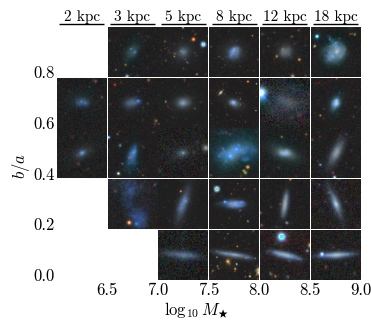

In [386]:
logm_bins = np.arange(6.0, 9.0 + 1e-9, 0.5)
ba_bins   = np.arange(0.0, 1.0 + 1e-9, 0.2)

fig, axes = plot_tight_image_grid(
    images, counts,
    xbins=logm_bins,
    ybins=ba_bins,
    xlabel=r"$\log_{10} M_{\bigstar}$",
    ylabel=r"$b/a$",
    xtick_fmt="{:.1f}",
    ytick_fmt="{:.1f}",
)

plt.savefig("/global/homes/v/virajvm/DESI2_LOWZ/quenched_fracs_nbs/paper_plots/dwarf_cutouts_ba.pdf")

plt.show()

## Nebular dust attenuation plot

In [26]:
# from stack_explore import deredshift_for_stacking
# 

In [27]:
# deredshift_for_stacking(use_invvar=False, delta_wave=0.2)


In [28]:
## load the ha/hb and av data points for the bins in halpha ew

In [29]:
import os
import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table
import pickle

STACK_PATH = "/pscratch/sd/v/virajvm/catalog_dr1_dwarfs/iron_spectra/stack_files/mstar_haew_5pct/"
FASTSPEC_HDU = 3
LINE_FLUX_TYPE = "FLUX"  # matches stack_direct_metallicity.py default

MSTAR_BINS = np.array([6.0, 6.5, 7.0, 7.5, 8.0, 8.25, 8.5, 8.75, 9.0, 9.25])
EW_TOKENS = ["ew_lt30", "ew_30_100", "ew_gt100"]
EW_COLORS = {"ew_lt30": "firebrick", "ew_30_100": "indigo", "ew_gt100": "mediumblue"}
EW_LABELS = {
    "ew_lt30": r"EW$\leq$30$\AA$",
    "ew_30_100": r"30$<$EW$\leq$100$\AA$",
    "ew_gt100": r"EW$>$100$\AA$",
}


def obs_ha_hb(tab, mode="total", line_flux_type=LINE_FLUX_TYPE,
              lo_pct=16, hi_pct=84, min_real=3):
    """
    Observed Halpha/Hbeta from a FastSpec stack table.

    mode="total"     -> row 0 (full stack); error from propagated IVAR.
    mode="bootstrap" -> rows 1:, the bootstrap refits; median ratio with the
                        lo/hi percentile range of the per-realization ratios.

    Returns (value, err_lo, err_hi):
      total     -> err_lo == err_hi (symmetric)
      bootstrap -> err_lo = median - p_lo, err_hi = p_hi - median (asymmetric)
    """
    ha_col = f"HALPHA_{line_flux_type}"
    hb_col = f"HBETA_{line_flux_type}"

    if mode == "total":
        ha = float(tab[ha_col][0]); hb = float(tab[hb_col][0])
        ha_ivar = float(tab[f"{ha_col}_IVAR"][0])
        hb_ivar = float(tab[f"{hb_col}_IVAR"][0])
        if not (np.isfinite(ha) and np.isfinite(hb) and hb > 0):
            return np.nan, np.nan, np.nan
        ratio = ha / hb
        if ha_ivar > 0 and hb_ivar > 0:
            ha_err = 1.0 / np.sqrt(ha_ivar)
            hb_err = 1.0 / np.sqrt(hb_ivar)
            err = np.abs(ratio) * np.sqrt((ha_err / ha) ** 2 + (hb_err / hb) ** 2)
        else:
            err = np.nan
        return ratio, err, err

    elif mode == "bootstrap":
        ha = np.asarray(tab[ha_col][1:], dtype=float)
        hb = np.asarray(tab[hb_col][1:], dtype=float)
        good = np.isfinite(ha) & np.isfinite(hb) & (hb > 0)
        if good.sum() < min_real:               # too few good realizations
            return np.nan, np.nan, np.nan
        ratios = ha[good] / hb[good]
        med = np.median(ratios)
        p_lo, p_hi = np.percentile(ratios, [lo_pct, hi_pct])
        return med, med - p_lo, p_hi - med

    else:
        raise ValueError(f"unknown mode: {mode!r}")


def collect_obs_hahb(ew_token, mode="total"):
    mstar_mid, val, err_lo, err_hi = [], [], [], []
    for i in range(len(MSTAR_BINS) - 1):
        mlo, mhi = MSTAR_BINS[i], MSTAR_BINS[i + 1]
        fpath = os.path.join(
            STACK_PATH,
            f"fastspec_stack_ALL_mstar_{mlo:.2f}_{mhi:.2f}_{ew_token}.fits",
        )
        if not os.path.exists(fpath):
            continue
        tab = Table.read(fpath, hdu=FASTSPEC_HDU)
        v, elo, ehi = obs_ha_hb(tab, mode=mode)
        mstar_mid.append(0.5 * (mlo + mhi))
        val.append(v); err_lo.append(elo); err_hi.append(ehi)
    return (np.array(mstar_mid), np.array(val),
            np.array(err_lo), np.array(err_hi))

    

MODE = "total"          # "total" or "bootstrap"
CACHE_PATH = os.path.join(STACK_PATH, f"obs_hahb_cache_{MODE}.pkl")
results = {}
for token in EW_TOKENS:
    x, y, ylo, yhi = collect_obs_hahb(token, mode=MODE)
    results[token] = {
        "x": x, "y": y, "yerr_lo": ylo, "yerr_hi": yhi,
        "label": EW_LABELS[token], "color": EW_COLORS[token],
    }
with open(CACHE_PATH, "wb") as f:
    pickle.dump(results, f)


In [30]:
def hahb_model(log_mstar):
    log_mstar_p = log_mstar*np.log(10)
    return 0.26*(log_mstar_p**2) - 4.25*(log_mstar_p) + 19.75


In [31]:

from cardelli_attenuation import k_ccm89

def balmer_to_Av(bd_obs, intrinsic_ratio=2.79, Rv=3.1):
    """
    Convert an observed Balmer decrement (Halpha/Hbeta) to A_V (mag)
    using a Cardelli+1989 curve. A_V = A(lambda)/k(lambda) with k normalized
    to k(V)=1, so A_V is just the differential-attenuation prefactor.
    """
    bd_obs = np.atleast_1d(bd_obs)
    kHb = k_ccm89(4861, Rv=Rv)
    kHa = k_ccm89(6563, Rv=Rv)
    return 2.5 * np.log10(bd_obs / intrinsic_ratio) / (kHb - kHa)


def ebv_to_balmer(ebv, ebv_err, intrinsic_ratio=2.86, Rv=3.1):
    """
    Convert E(B-V) to observed Balmer decrement (Hα/Hβ) with error propagation.

    The observed ratio is:
        R = R0 * 10^( E(B-V) * (k_Hβ - k_Hα) / 2.5 )

    The propagated uncertainty via dR/d(E(B-V)):
        σ_R = σ_EBV * R * ln(10)/2.5 * (k_Hβ - k_Hα)

    Parameters
    ----------
    ebv : array_like
        E(B-V) values [mag].
    ebv_err : array_like
        1σ uncertainties on E(B-V) [mag].
    intrinsic_ratio : float
        Intrinsic Hα/Hβ (Case B); default 2.86 (T_e = 10^4 K).
    Rv : float
        Total-to-selective extinction ratio; default 3.1.

    Returns
    -------
    balmer_ratio : ndarray
        Observed Hα/Hβ ratio.
    balmer_err : ndarray
        1σ uncertainty on the observed ratio.
    """
    ebv     = np.asarray(ebv,     dtype=float)
    ebv_err = np.asarray(ebv_err, dtype=float)

    kHb = k_ccm89(4861, Rv=Rv)
    kHa = k_ccm89(6563, Rv=Rv)
    dk  = kHb - kHa                          # > 0 since k decreases with λ

    balmer_ratio = intrinsic_ratio * 10**((ebv * dk) / 2.5)
    balmer_err   = ebv_err * balmer_ratio * (np.log(10) / 2.5) * dk

    return balmer_ratio, balmer_err


In [32]:

# CACHE_PATH_2 = os.path.join(STACK_PATH, f"obs_hahb_cache_bootstrap.pkl")

# with open(CACHE_PATH_2, "rb") as f:
#     results_boot = pickle.load(f)

In [33]:
# results_boot

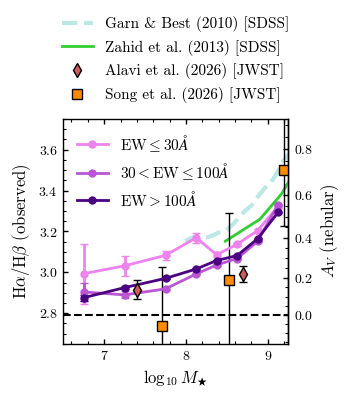

In [34]:


CACHE_PATH = os.path.join(STACK_PATH, f"obs_hahb_cache_{MODE}.pkl")

with open(CACHE_PATH, "rb") as f:
    results = pickle.load(f)

fig, ax = make_subplots(ncol=1, nrow=1, plot_size=2.25, return_fig=True, 
                        col_spacing=[MARGIN_LABEL-0.35, MARGIN_LABEL - 0.35],
                      row_spacing=[MARGIN_LABEL-0.4, MARGIN_LABEL + 0.2])


#####

colors = ["violet", "mediumorchid", "indigo"]

plot_item = 0
for token, d in results.items():
    x, y, ylo, yhi = d["x"], d["y"], d["yerr_lo"], d["yerr_hi"]
    if len(x) == 0:
        continue
    has_err = np.isfinite(ylo) & np.isfinite(yhi) & ((ylo + yhi) > 0)
    if np.any(has_err):
        ax[0].errorbar(
            x[has_err], y[has_err],
            yerr=[ylo[has_err], yhi[has_err]],   # [lower, upper] -> asymmetric
            fmt="o-", capsize=3, lw=2, alpha=1,
            color=colors[plot_item], label=d["label"],
        )
    no_err = ~has_err & np.isfinite(y)
    if np.any(no_err):
        ax[0].plot(x[no_err], y[no_err], "o-", lw=2,
                   color=colors[plot_item], alpha=1,
                   label=d["label"] if not np.any(has_err) else None)

    plot_item += 1



#data from Zahid et al. 2013
mstar_z13 = [8.481751824817518,8.903284671532846 , 9.166058394160583, 9.357664233576642, 9.505474452554743 ]
hahb_z13 = [ 3.1524316318368166, 3.2595865413458656, 3.382424257574243, 3.5105208229177087, 3.6489663533646635]

mstar_jades = [7.708812260536399, 8.528735632183908,9.203065134099617 ]
hahb_jades = [2.7395939218599326, 2.9628587067010725 ,  3.498058227122268]
hahb_jades_err = [ 2.7259884796830622 - 2.4402220658378306, 
                   2.9628587067010725 - 2.636328094456174,
                   3.7837725128365545 - 3.511663669299139]


#this is the mean data point!
alavi26_mstar = [7.4,8.7]
alavi26_ebv = np.array([0.06, 0.14])
alavi26_ebv_err = np.array([0.05, 0.04])

## from Garn 2010
log_mass_G10 = np.array([
    7.9897189349112425, 8.081028106508876, 8.167548076923078,
    8.244489644970415, 8.321394230769231, 8.407895710059172,
    8.48960798816568, 8.566475591715976, 8.643324704142012,
    8.72498150887574, 8.806656804733727, 8.869082840236686,
    8.960336538461538, 9.037204142011834, 9.11403476331361,
    9.186039201183432, 9.26769600591716, 9.339700443786983,
])

A_Halpha_G10 = np.array([
    0.27692307692307727, 0.29230769230769305, 0.3000000000000007,
    0.29230769230769305, 0.3000000000000007, 0.3153846153846156,
    0.32307692307692326, 0.3461538461538467, 0.3769230769230769,
    0.407692307692308, 0.43076923076923146, 0.4615384615384621,
    0.5, 0.5230769230769234, 0.5615384615384618,
    0.6076923076923082, 0.6384615384615389, 0.6846153846153848,
])

def AHa_to_balmer_G10(A_Halpha, intrinsic_ratio=2.86):
    """
    Convert Garn & Best (2010) A_Halpha (mag) -> observed Halpha/Hbeta.
    G&B use the Calzetti+2000 law (their Eq. 1) with intrinsic ratio 2.86,
    so we invert with Calzetti k-values, NOT the CCM89 machinery used elsewhere.
    """
    k_Hb, k_Ha = 4.5981, 3.3258   # Calzetti+2000, R_V=4.05, at 4861/6563 A
    A_Halpha = np.asarray(A_Halpha, dtype=float)
    return intrinsic_ratio * 10**(A_Halpha * (k_Hb - k_Ha) / (2.5 * k_Ha))

hahb_G10 = AHa_to_balmer_G10(A_Halpha_G10)

#note that ebv * k_halpha = a_halpha

ax[0].plot( log_mass_G10, hahb_G10, color="lightseagreen",lw=3,alpha=0.3,ls = "--" )

ax[0].plot(mstar_z13, hahb_z13, color = "limegreen",lw=2)

#add error bars to these points!

alavi26_hahb, alavi26_hahb_err = ebv_to_balmer(alavi26_ebv, alavi26_ebv_err, intrinsic_ratio=2.86, Rv=3.1)


ax[0].errorbar( x=alavi26_mstar, y=alavi26_hahb, yerr =alavi26_hahb_err,
                color = "indianred", ls = "none", marker="d",markersize =7,markeredgecolor="k",capsize = 3, ecolor="k", elinewidth=1)


#jades measurement from Song et al. 
ax[0].errorbar(x=mstar_jades, y=hahb_jades, yerr = hahb_jades_err,
               ls="none",color = "darkorange", marker="s", markersize =7.5, markeredgecolor="k",capsize = 3, ecolor="k", elinewidth=1)

ax[0].set_ylabel(r"H$\alpha$/H$\beta$ (observed)")

ax[0].set_ylim(2.65, 3.75) 
ax[0].axhline(y=2.79, color="k",ls="--")

for axi in ax:
    axi.set_xlim(6.5, 9.25)


ax[0].set_xlabel(r"$\log_{10} M_{\bigstar}$")

ax[0].tick_params(axis="y", which="both", right=False)

import matplotlib.lines as mlines
import matplotlib.container as container

# ── inside legend: EW bins as lines only ─────────────────────────────────────
ew_handles, ew_labels = ax[0].get_legend_handles_labels()
line_handles = [h[0] if isinstance(h, container.ErrorbarContainer) else h
                for h in ew_handles]

ew_legend = ax[0].legend(line_handles, ew_labels, frameon=False,
                         loc="upper left")   # or wherever it sits best

ax[0].add_artist(ew_legend)   # <-- re-pins it so the next call doesn't wipe it

# ── above-panel legend: survey comparison points ──────────────────────────────
survey_handles = [
    mlines.Line2D([], [], color="lightseagreen", lw=3, alpha=0.3, ls="--",
                  label="Garn & Best (2010) [SDSS]"),
    mlines.Line2D([], [], color="limegreen", lw=2,
                  label="Zahid et al. (2013) [SDSS]"),
    mlines.Line2D([], [], color="indianred", marker="d", markersize=7,
                  markeredgecolor="k", ls="none",
                  label="Alavi et al. (2026) [JWST]"),
    mlines.Line2D([], [], color="darkorange", marker="s", markersize=7.5,
                  markeredgecolor="k", ls="none",
                  label="Song et al. (2026) [JWST]"),
]

ax[0].legend(
    handles=survey_handles,
    loc="lower center",
    bbox_to_anchor=(0.5, 1.01),
    ncol=1,
    frameon=False,
)
######


INTRINSIC_RATIO = 2.79
_kHb = k_ccm89(4861, Rv=3.1)
_kHa = k_ccm89(6563, Rv=3.1)
_COEFF = 2.5 / (_kHb - _kHa)          # ~7.215

def _bd_to_av(bd):
    bd = np.asarray(bd, dtype=float)
    return _COEFF * np.log10(bd / INTRINSIC_RATIO)

def _av_to_bd(av):
    av = np.asarray(av, dtype=float)
    return INTRINSIC_RATIO * 10**(av / _COEFF)

secax = ax[0].secondary_yaxis("right", functions=(_bd_to_av, _av_to_bd))
secax.set_ylabel(r"$A_V$ (nebular)")

plt.savefig("/global/homes/v/virajvm/DESI2_LOWZ/quenched_fracs_nbs/paper_plots/desi_dwarfs_nebular_dust.pdf")

plt.show()

In [35]:
## fit a functional relation to this now!!

In [59]:
all_x = []
all_y = []
all_yerr = []

result_num = 0
for token, d in results.items():

    if result_num <= 10:
        x, y, ylo, yhi = d["x"], d["y"], d["yerr_lo"], d["yerr_hi"]
        if len(x) == 0:
            continue
    
        all_x.append( x[has_err] )
        all_y.append( y[has_err] )
        all_yerr.append( 0.5*(ylo[has_err] + yhi[has_err])  )

    result_num+= 1

all_x = np.concatenate(all_x)
all_y = np.concatenate(all_y)
all_yerr = np.concatenate(all_yerr)



A  = 10.000 ± 14.049
k  = 1.287 ± 0.054
x0 = 11.521 ± 1.238


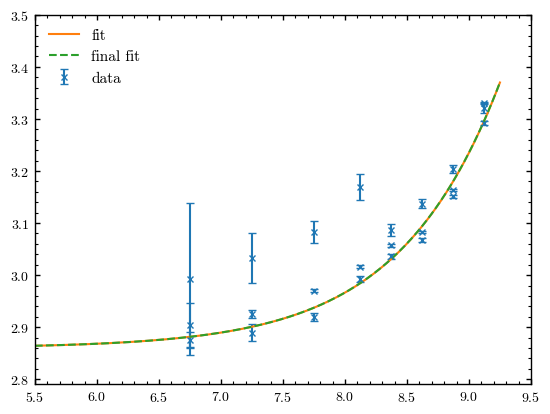

In [80]:
def model(x, A, k, x0):
    return 2.86 + A / (1 + np.exp(-k * (x - x0)))

# x0 ~ where the midpoint of the rise is, looks ~8 from your plot
# A ~ total rise, your data goes from ~2.9 to ~3.35, so A ~ 0.5-0.6
# k ~ sharpness, small for gradual
p0 = [0.6, 0.8, 8.0]
bounds = ([0.1, 0.01, 5.5], [10.0, 5.0, 20.0])

popt, pcov = curve_fit(
    model, all_x, all_y,
    p0=p0,
    sigma=all_yerr,
    absolute_sigma=True,
    bounds=bounds
)

A_fit, k_fit, x0_fit = popt
perr = np.sqrt(np.diag(pcov))
print(f"A  = {A_fit:.3f} ± {perr[0]:.3f}")
print(f"k  = {k_fit:.3f} ± {perr[1]:.3f}")
print(f"x0 = {x0_fit:.3f} ± {perr[2]:.3f}")

def model_hahb(log_mstar, A=10.000, k=1.287, x0=11.521):
    '''
    Model fit to the stacked balmer decrements! Used to do average internal nebular dust corrections
    '''
    return 2.86 + A / (1 + np.exp(-k * (log_mstar - x0)))


x_plot = np.linspace(5.5, 9.25, 300)
plt.errorbar(x=all_x, y=all_y, yerr=all_yerr, ls="none", capsize=3, marker="x", label="data")
plt.plot(x_plot, model(x_plot, *popt), label="fit")

plt.plot(x_plot, model_hahb(x_plot), label="final fit", ls = "--")


plt.xlim([5.5, 9.5])
plt.ylim([2.79, 3.5])
plt.legend()
plt.show()

## Boxflux vs. flux

In [14]:
new_fspec_cat = Table.read("/pscratch/sd/v/virajvm/desi_dwarf_catalogs/fastspecfit_custom_run/iron/catalogs/fastspec-iron-dr1-dwarfs.fits", hdu = 3)
new_fspec_cat_hdu1 = Table.read("/pscratch/sd/v/virajvm/desi_dwarf_catalogs/fastspecfit_custom_run/iron/catalogs/fastspec-iron-dr1-dwarfs.fits", hdu = 1)

      

/tmp/ipykernel_359048/1400104196.py:19: RuntimeWarning: divide by zero encountered in divide
  ratio = boxflux / flux
/tmp/ipykernel_359048/1400104196.py:19: RuntimeWarning: overflow encountered in divide
  ratio = boxflux / flux
/tmp/ipykernel_359048/1400104196.py:19: RuntimeWarning: invalid value encountered in divide
  ratio = boxflux / flux
/tmp/ipykernel_359048/1400104196.py:36: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[0].legend(loc="lower left", markerscale=4, frameon=True)


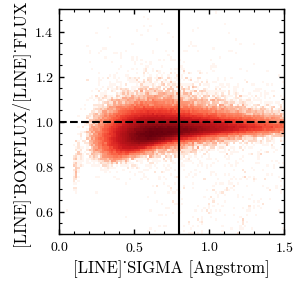

In [34]:
# === BOXFLUX/FLUX vs. line sigma diagnostic ===
# Reproduces the FastSpecFit boxflux-vs-gaussflux validation plot.
# To switch lines, change `line` only -- the rest wavelength is looked up below.
restwave_dict = {"HALPHA": 6564.60, "OIII_5007": 5008.240}  # vacuum rest wavelengths [Angstrom]
line     = "HALPHA"  
restwave = restwave_dict[line]

C_LIGHT = 299792.458   

flux      = new_fspec_cat[f"{line}_FLUX"].data
flux_ivar = new_fspec_cat[f"{line}_FLUX_IVAR"].data
boxflux   = new_fspec_cat[f"{line}_BOXFLUX"].data
sigma_kms = new_fspec_cat[f"{line}_SIGMA"].data      # FastSpecFit stores SIGMA in km/s
z         = new_fspec_cat_hdu1["Z"].data

#rest frame line width
sigma_ang = sigma_kms * restwave * (1.0 + z) / C_LIGHT

ratio = boxflux / flux
snr   = flux * np.sqrt(flux_ivar)

#quality cuts
mask = (flux > 0) & (boxflux > 0) & (snr > 20) & np.isfinite(ratio) & np.isfinite(sigma_ang)

fig, ax = make_subplots(ncol=1, nrow=1, plot_size=2.25, return_fig=True,
                        col_spacing=[MARGIN_LABEL, MARGIN_PAD],
                        row_spacing=[MARGIN_LABEL, MARGIN_PAD])

ax[0].hist2d(sigma_ang[mask], ratio[mask], range= ((0,1.5), (0.5,1.5)), bins=100, rasterized=True,cmap="Reds",norm=LogNorm())
ax[0].axhline(1.0, color="k", ls="--")
ax[0].axvline(0.8, color="k", ls="-")
ax[0].set_xlim(0, 1.5)
ax[0].set_ylim(0.5, 1.5)
ax[0].set_xlabel("[LINE]_SIGMA [Angstrom]")
ax[0].set_ylabel("[LINE]_BOXFLUX/[LINE]_FLUX")
ax[0].legend(loc="lower left", markerscale=4, frameon=True)
plt.show()


## Searching for broad components in emfit catalog

In [172]:
import sys
import os

rootdir = '/global/u1/v/virajvm/'
sys.path.append(os.path.join(rootdir, 'DESI2_LOWZ/desi_dwarfs/code'))


In [163]:
emfit_cat = Table.read("/global/cfs/cdirs/desi/public/dr1/vac/dr1/emfit/v2.3/emfit-dr1-v2.3.fits")

In [164]:
emfit_cat = emfit_cat["TARGETID","Z","HA_N_SIGMA","HA_N_SIGMA_ERR", "HA_N_SIGMA_FLAG", "HA_OUT_SIGMA", "HA_OUT_SIGMA_ERR", "HA_OUT_SIGMA_FLAG", "HA_B_SIGMA", "HA_B_SIGMA_ERR","HA_B_SIGMA_FLAG"]



In [165]:
mask = (emfit_cat["HA_OUT_SIGMA_FLAG"] == 0) | (emfit_cat["HA_N_SIGMA_FLAG"] == 0)  | (emfit_cat["HA_B_SIGMA_FLAG"] == 0) 

In [167]:
emfit_cat_v2 = emfit_cat[mask]

In [169]:
emfit_cat_broad = emfit_cat_v2[emfit_cat_v2["HA_B_SIGMA"] > 0]

In [176]:
main_tgids = main["TARGETID"].data
broad_tgids = emfit_cat_broad["TARGETID"].data

In [177]:
len(main_tgids), len(broad_tgids)

(451538, 180581)

In [181]:
main_broad_det = main[np.isin(main_tgids, broad_tgids)]

In [186]:
emfit_cat_broad[emfit_cat_broad["TARGETID"]==39627334671665216]

TARGETID,Z,HA_N_SIGMA,HA_N_SIGMA_ERR,HA_N_SIGMA_FLAG,HA_OUT_SIGMA,HA_OUT_SIGMA_ERR,HA_OUT_SIGMA_FLAG,HA_B_SIGMA,HA_B_SIGMA_ERR,HA_B_SIGMA_FLAG
,,km / s,km / s,,km / s,km / s,,km / s,km / s,
int64,float64,float64,float64,int64,float64,float64,int64,float64,float64,int64
39627334671665216,0.03948277090766776,21.592000969012176,0.6303051558768068,0,0.0,0.0,-1,134.96768488612636,21.47711022488681,0


In [190]:
main_broad_26A = main_broad_det[(main_broad_det["Z"] < 0.01) & (main_broad_det["DEC"] < 10) & ( (main_broad_det["RA"] > 80) | (main_broad_det["RA"] < 40) ) ]  

In [201]:
main_broad_26A

for i in range(len(main_broad_26A)):
    print(f'TGID={main_broad_26A["TARGETID"].data[i]},RA,DEC={main_broad_26A["RA"].data[i]:.4f},{main_broad_26A["DEC"].data[i]:.4f},LogM={main_broad_26A["LOG_MSTAR_SAGA"].data[i]:.1f}, Z={main_broad_26A["Z"].data[i]:.3f}, MASKBIT={main_broad_26A["DWARF_MASKBIT"].data[i]:d} ')
    
    temp = emfit_cat_broad[emfit_cat_broad["TARGETID"] == main_broad_26A["TARGETID"].data[i]]
    print(f'HA_B_SIGMA = {temp["HA_B_SIGMA"].data[0]:.1f} +/- {temp["HA_B_SIGMA_ERR"].data[0]:.1f}')
    print("---")

TGID=39627679858691316,RA,DEC=226.4978,-4.4615,LogM=8.5, Z=0.007, MASKBIT=0 
HA_B_SIGMA = 136.5 +/- 4.8
---
TGID=39627721143225249,RA,DEC=170.1505,-2.7436,LogM=8.2, Z=0.008, MASKBIT=0 
HA_B_SIGMA = 163.6 +/- 16.8
---
TGID=39627742769053897,RA,DEC=19.0052,-1.7664,LogM=6.4, Z=0.006, MASKBIT=0 
HA_B_SIGMA = 170.4 +/- 31.4
---
TGID=39627788411473940,RA,DEC=219.6940,-0.0272,LogM=7.6, Z=0.006, MASKBIT=0 
HA_B_SIGMA = 260.9 +/- 6.6
---
TGID=39627806086268813,RA,DEC=193.1109,0.6951,LogM=7.0, Z=0.010, MASKBIT=0 
HA_B_SIGMA = 567.0 +/- 56.3
---
TGID=39627995329070768,RA,DEC=350.2326,8.3853,LogM=8.1, Z=0.009, MASKBIT=0 
HA_B_SIGMA = 158.9 +/- 2.1
---
TGID=39636701349417815,RA,DEC=348.6967,4.6386,LogM=8.8, Z=0.010, MASKBIT=0 
HA_B_SIGMA = 649.8 +/- 12.8
---
TGID=39627899812187631,RA,DEC=23.1668,4.6415,LogM=8.0, Z=0.007, MASKBIT=0 
HA_B_SIGMA = 191.6 +/- 16.7
---
TGID=39627905885538609,RA,DEC=26.1739,4.8943,LogM=8.1, Z=0.005, MASKBIT=0 
HA_B_SIGMA = 214.9 +/- 8.9
---
TGID=39627595087614545,RA,DEC=1

In [4]:
from astropy.table import Table